# Breast Ultrasound Segmentation — UltraSam on BUSI
## Windows / RTX 3080 — validation Dice + IoU every 500 iterations

This version keeps the official UltraSam architecture and prompt pipeline, but adds a BUSI-specific segmentation evaluator during training.

### What is new
- Validation every **500 iterations**.
- Prints **Val Dice** and **Val IoU** during training.
- Also reports Precision, Recall/Sensitivity, Specificity and Accuracy.
- Saves the **best checkpoint by validation Dice**.
- Keeps COCO segmentation mAP in parallel for reference.
- Uses the fixed BUSI COCO category `object`.
- Uses `batch_size=1` + gradient accumulation 8 for an RTX 3080.
- Uses Windows-safe dataloader settings.

The validation metric is computed from the predicted binary mask versus the ground-truth lesion mask, image by image, then macro-averaged over the validation split.

**Use Jupyter kernel: `Python (UltraSam)`**

Because this changes the training/evaluation hooks, use this notebook as a new run rather than continuing the earlier 30,000-iteration process.


## UltraSam Transfer Learning — Frozen ViT Image Encoder

This version loads the released `UltraSam.pth`, freezes the official `model.backbone` (`mmpretrain.ViTSAM` image encoder), and trains the prompt encoder plus mask/segmentation decoder/head. The frozen backbone is kept in evaluation mode during training.

Training is shortened from 30,000 to **10,000 iterations**, validation runs every 500 iterations, and the best checkpoint is selected by BUSI Dice. Gradient accumulation remains 8.

**Important:** this remains GT-box-prompted segmentation, not fully automatic segmentation.


## 1. Setup: environment, imports, device check, experiment configuration

In [1]:
# UltraSam requires the dedicated OpenMMLab environment.
# Do not install/upgrade CUDA/PyTorch packages inside another benchmark environment.
#
# Required Jupyter kernel:
#     Python (UltraSam)

try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print("Local Windows/Jupyter mode detected.")


Local Windows/Jupyter mode detected.


In [2]:
import os
import gc
import json
import math
import time
import random
import datetime
import warnings
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from scipy.ndimage import binary_erosion, distance_transform_edt, generate_binary_structure
from scipy.spatial.distance import directed_hausdorff

import albumentations as A
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__, "| Albumentations:", A.__version__)
print("Using device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0),
          f"({torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB)")
else:
    print("No GPU detected — training will run on CPU and AMP will be disabled.")

PyTorch: 2.0.0+cu118 | Albumentations: 1.4.18
Using device: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU (8.0 GB)


C:\Users\pro\anaconda3\envs\UltraSam\lib\site-packages\albumentations\__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
C:\Users\pro\anaconda3\envs\UltraSam\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Experiment configuration (suggested settings)

All tunable settings live in this one cell. The defaults are the CFFormer protocol plus the suggestions below; keep them **identical across models** so that F1 differences come from the architecture only.

| Setting | Value | Why |
|---|---|---|
| Image size | 224 | paper protocol; five models are hard-wired to 224 |
| Epochs | 130 (10 warm-up) | paper; poly decay keeps improving late, so early stopping only after warm-up with patience 40 |
| Batch | 16 effective | paper; automatic micro-batch + gradient accumulation on an 8 GB GPU |
| Optimiser | AdamW 3e-4, wd 3e-5 | paper; replaces Adam 1e-4 + ReduceLROnPlateau (whose patience of 50 never fired before early stopping at 10) |
| Loss | 0.5·BCE + 0.5·Dice | paper (DiceCE, λ = 0.5) |
| Augmentation | `"ultrasound"` | no vertical flip (anatomically implausible in breast US) + speckle-like noise and contrast; `"paper"` reproduces CFFormer exactly |
| Seeds | 42 → also 43, 44 | the 59-image test set is small; differences under ~2 F1 points are within seed noise |

In [3]:
# =====================================================================
#  EXPERIMENT CONFIGURATION  (identical in every model notebook except
#  MODEL_NAME / MODEL_KEY / PRETRAINED — keep it that way for a fair test)
# =====================================================================
MODEL_NAME = "UltraSam"
MODEL_KEY = "ultrasam_box_prompt_transfer"          # results go to <project_root>/busi_clean_benchmark/<MODEL_KEY>/seed<SEED>/
PRETRAINED = True          # ImageNet weights as in the CFFormer paper ("*" models) / official code

# ---------------- data ----------------
IMAGE_SIZE = 1024                     # CFFormer protocol; MISSFormer, FAT-Net, TransUNet, HiFormer, BEFUnet are hard-wired to 224
SPLIT_SEED = 42                      # ONE split for all models (80/10/10, stratified, saved to disk on first run)
SEED = 42                            # training seed. For a reliable comparison run SEED = 42, 43, 44
INCLUDE_NORMAL_IN_TRAINING = True    # your cleaned set keeps 90 normal (empty-mask) images; the paper removed them.
                                     # Test metrics are ALWAYS reported for all / lesion-only (paper-comparable) / per class.

# ---------------- augmentation ----------------
# "paper"      : exact CFFormer Sec. 4.1 — RandomResizedCrop(scale 0.5-1), HFlip 0.5, VFlip 0.5, Rotate ±15° (p=0.6)
# "ultrasound" : suggested for breast ultrasound — same crop/HFlip/rotation, NO vertical flip (skin line must stay on top,
#                posterior acoustic shadowing below a lesion is a diagnostic cue), + mild brightness/contrast/gamma and
#                multiplicative (speckle-like) noise. No CoarseDropout (it can erase small lesions).
# "none"       : resize only
AUG_PRESET = "ultrasound"

# ---------------- optimisation (CFFormer Sec. 4.1) ----------------
NUM_EPOCHS = 30                     # 10 warm-up + 120 training epochs
WARMUP_EPOCHS = 1                   # linear warm-up, then "poly" decay
POLY_POWER = 0.9
BATCH_SIZE = 16                      # effective batch size
LR = 1e-4
WEIGHT_DECAY = 3e-5
BETAS = (0.9, 0.999)
LOSS_LAMBDA = 0.5                    # DiceCE = λ·BCE + (1-λ)·Dice   (λ = 0.5 in the paper)
GRAD_CLIP_NORM = 1.0                 # stabilises transformer training under AMP (None = off)
EARLY_STOPPING_PATIENCE = 40         # epochs without validation-F1 gain, counted after warm-up. None = run all 130 (paper)
AUTO_MICRO_BATCH = True              # if 16 images do not fit on the GPU, use a smaller micro-batch + gradient accumulation
USE_AMP = True                       # bfloat16 on RTX 30/40-series, float16 + GradScaler otherwise
DETERMINISTIC = False                # True = bit-reproducible but slower cuDNN kernels
USE_TTA = False                      # horizontal-flip test-time augmentation (reported as an extra; keep False for the main table)
NUM_WORKERS = 0 if os.name == "nt" else 2   # Windows notebooks cannot pickle notebook-defined Datasets -> 0

# quick pipeline check on a tiny run:  set environment variable BUSI_SMOKE_TEST=1
SMOKE_TEST = os.environ.get("BUSI_SMOKE_TEST", "0") == "1"
if SMOKE_TEST:
    NUM_EPOCHS, WARMUP_EPOCHS, BATCH_SIZE, EARLY_STOPPING_PATIENCE = 2, 1, 4, None
if os.environ.get("BUSI_NO_PRETRAINED", "0") == "1":
    PRETRAINED = True

print(f"{MODEL_NAME} | pretrained={PRETRAINED} | {IMAGE_SIZE}px | aug={AUG_PRESET} | "
      f"epochs={NUM_EPOCHS} (warm-up {WARMUP_EPOCHS}) | batch={BATCH_SIZE} | lr={LR} | seed={SEED}")

UltraSam | pretrained=True | 1024px | aug=ultrasound | epochs=30 (warm-up 1) | batch=16 | lr=0.0001 | seed=42


## 2. Build the dataset DataFrame

This uses the same `Benign / Malignant / Normal` folder layout and pairing logic as your FCN8 notebook.

In [4]:
# Google Colab / Google Drive paths
if IN_COLAB:
    project_root = "/content/drive/MyDrive"
else:
    # Local fallback: edit only this path when running outside Colab.
    project_root = r"C:\Users\pro\Breast cancer aldubayani models"
project_root = os.environ.get("BUSI_PROJECT_ROOT", project_root)

base_dir = os.path.join(project_root, "data_breast")                 # cleaned dataset (582 images)
benchmark_root = os.path.join(project_root, "busi_clean_benchmark")  # all runs of all models
weights_dir = os.path.join(project_root, "pretrained_weights")       # downloaded backbone checkpoints
os.makedirs(benchmark_root, exist_ok=True)
os.makedirs(weights_dir, exist_ok=True)

if not os.path.isdir(base_dir):
    raise FileNotFoundError(
        f"Dataset folder not found: {base_dir}\n"
        "In Colab, make sure Drive is mounted and data_breast is directly under MyDrive.\n"
        "Outside Colab, edit project_root above."
    )

for category in ["Benign", "Malignant", "Normal"]:
    image_dir = os.path.join(base_dir, category, "images")
    mask_dir = os.path.join(base_dir, category, "masks")
    if not os.path.isdir(image_dir):
        raise FileNotFoundError(f"Missing image folder: {image_dir}")
    if not os.path.isdir(mask_dir):
        raise FileNotFoundError(f"Missing mask folder: {mask_dir}")
    print(f"{category}: {len(os.listdir(image_dir))} images, {len(os.listdir(mask_dir))} masks")

Benign: 319 images, 319 masks
Malignant: 173 images, 173 masks
Normal: 90 images, 90 masks


In [5]:
categories = ["Benign", "Malignant", "Normal"]
data = []

for category in categories:
    image_dir = os.path.join(base_dir, category, "images")
    mask_dir = os.path.join(base_dir, category, "masks")
    for filename in sorted(os.listdir(image_dir)):
        image_path = os.path.join(image_dir, filename)
        mask_path = os.path.join(mask_dir, filename)
        # keep only pairs that actually have a matching mask
        if os.path.exists(mask_path):
            data.append({"Category": category.lower(), "Image_Path": image_path, "Label_Path": mask_path})

df = pd.DataFrame(data)
df = df.sample(frac=1, random_state=SPLIT_SEED).reset_index(drop=True)   # same shuffling as your FCN8 notebook
df["Rel_Image"] = df["Image_Path"].apply(lambda p: os.path.relpath(p, base_dir).replace("\\", "/"))
df["Rel_Label"] = df["Label_Path"].apply(lambda p: os.path.relpath(p, base_dir).replace("\\", "/"))

print(df["Category"].value_counts())
print(df.shape)

Category
benign       319
malignant    173
normal        90
Name: count, dtype: int64
(582, 5)


## 3. Train / validation / test split (shared by all models) + leakage check

The split uses exactly the same stratified calls as your FCN8 notebook, so it reproduces the same 465/58/59 images. It is written to `busi_clean_benchmark/splits/` on the first run and **re-loaded by every other notebook**, so all models see identical images.

The second cell searches for remaining near-duplicates between training and evaluation images. The letter showed that duplicates leaking into the test set inflate reported scores.

In [6]:
split_dir = os.path.join(benchmark_root, "splits")
os.makedirs(split_dir, exist_ok=True)
split_csv = os.path.join(split_dir, f"split_seed{SPLIT_SEED}.csv")

if os.path.exists(split_csv):
    split_df = pd.read_csv(split_csv)
    if set(split_df["Rel_Image"]) != set(df["Rel_Image"]):
        raise RuntimeError(f"The dataset folder changed since {split_csv} was written. "
                           "Delete that file to create a new split (and re-run ALL models).")
    df = df.drop(columns=[c for c in ["Split"] if c in df]).merge(split_df[["Rel_Image", "Split"]], on="Rel_Image")
    print(f"Loaded the shared split from {split_csv}")
else:
    # identical calls to your FCN8 notebook -> identical train/valid/test split
    train_df, temp_df = train_test_split(df, test_size=0.2, random_state=SPLIT_SEED, stratify=df["Category"])
    valid_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SPLIT_SEED, stratify=temp_df["Category"])
    df["Split"] = "train"
    df.loc[valid_df.index, "Split"] = "valid"
    df.loc[test_df.index, "Split"] = "test"
    df[["Category", "Rel_Image", "Rel_Label", "Split"]].to_csv(split_csv, index=False)
    print(f"Created and saved the shared split: {split_csv}")

def _paths(split, keep_normal=True):
    d = df[df["Split"] == split]
    if not keep_normal:
        d = d[d["Category"] != "normal"]
    return d["Image_Path"].tolist(), d["Label_Path"].tolist(), d["Category"].tolist()

train_x, train_y, train_cat = _paths("train", keep_normal=INCLUDE_NORMAL_IN_TRAINING)
valid_x, valid_y, valid_cat = _paths("valid")
test_x, test_y, test_cat = _paths("test")

print(pd.crosstab(df["Split"], df["Category"], margins=True))
print(f"Dataset Size:\nTrain: {len(train_x)} - Valid: {len(valid_x)} - Test: {len(test_x)}")

Loaded the shared split from C:\Users\pro\Breast cancer aldubayani models\busi_clean_benchmark\splits\split_seed42.csv
Category  benign  malignant  normal  All
Split                                   
test          32         18       9   59
train        255        138      72  465
valid         32         17       9   58
All          319        173      90  582
Dataset Size:
Train: 465 - Valid: 58 - Test: 59


In [7]:
# Near-duplicate leakage check (the Letter to the Editor found 155 duplicated / near-identical images in BUSI).
# 64-bit difference hash of each image; pairs with Hamming distance <= 5 between TRAIN and VALID/TEST are listed.
def dhash(path, hash_size=8):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (hash_size + 1, hash_size), interpolation=cv2.INTER_AREA)
    return np.packbits((img[:, 1:] > img[:, :-1]).flatten())

tr = df[df["Split"] == "train"].reset_index(drop=True)
ev = df[df["Split"] != "train"].reset_index(drop=True)
h_tr = np.stack([dhash(p) for p in tr["Image_Path"]])
h_ev = np.stack([dhash(p) for p in ev["Image_Path"]])
ham = np.unpackbits(h_tr[:, None, :] ^ h_ev[None, :, :], axis=-1).sum(-1)
pairs = np.argwhere(ham <= 5)
print(f"Train vs valid/test near-duplicate pairs (Hamming <= 5): {len(pairs)}")
for i, j in pairs[:20]:
    print(f"  d={ham[i, j]:2d}  train: {tr.loc[i, 'Rel_Image']}  <->  {ev.loc[j, 'Split']}: {ev.loc[j, 'Rel_Image']}")
if len(pairs):
    print("Open these pairs and check them visually; true duplicates inflate test F1 (information leakage).")

Train vs valid/test near-duplicate pairs (Hamming <= 5): 0


## 4. Utilities

In [8]:
def seeding(seed, deterministic=False):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = deterministic
    torch.backends.cudnn.benchmark = not deterministic

def create_dir(path):
    os.makedirs(path, exist_ok=True)

def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

def print_and_save(file_path, data_str):
    print(data_str)
    with open(file_path, "a") as file:
        file.write(data_str)
        file.write("\n")

def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

seeding(SEED, DETERMINISTIC)

## 5. Model — UltraSam

- **Source:** CAMMA-public/UltraSam official release.
- **Backbone:** SAM ViT-B adapted to ultrasound.
- **Pretraining:** UltraSam US-43d checkpoint.
- **Prompt:** lesion bounding box derived from the ground-truth mask.
- **Input:** SAM-style 1024×1024 resize/pad internally.
- **Important:** this is a prompted segmentation experiment, not an automatic U-Net-style experiment.


In [9]:
# ---------------------------------------------------------------------------
# UltraSam official source / checkpoint setup + strict environment diagnostic
# ---------------------------------------------------------------------------
import sys
import os
import shutil
import zipfile
import urllib.request
import subprocess
import importlib
from pathlib import Path

print("=" * 90)
print("PYTHON / CUDA / OPENMMLAB PREFLIGHT")
print("=" * 90)
print("Python executable :", sys.executable)
print("Python version    :", sys.version.split()[0])
print("PyTorch version   :", torch.__version__)
print("CUDA in PyTorch   :", torch.version.cuda)
print("CUDA available    :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU               :", torch.cuda.get_device_name(0))

# ---------------------------------------------------------------------------
# Your local UltraSam location.
# The code accepts either:
#   ...\Advanced model\Ultrasam                 <- repository itself
# or
#   ...\Advanced model\Ultrasam\UltraSam        <- repository nested one level
# ---------------------------------------------------------------------------
USER_ULTRASAM_HOME = Path(
    r"C:\Users\pro\Breast cancer aldubayani models\Advanced models\Ultrasam"
)

def is_ultrasam_repo(p: Path) -> bool:
    return (
        p.exists()
        and (p / "configs").exists()
        and (p / "configs" / "UltraSAM").exists()
    )

def locate_ultrasam_repo(base: Path) -> Path:
    candidates = [
        base,
        base / "UltraSam",
        base / "UltraSam-main",
        Path.cwd() / "UltraSam",
        Path.cwd() / "_external_models" / "UltraSam",
    ]
    for p in candidates:
        if is_ultrasam_repo(p):
            return p.resolve()

    # One-level recursive fallback.
    if base.exists():
        for p in base.iterdir():
            if p.is_dir() and is_ultrasam_repo(p):
                return p.resolve()

    searched = "\n".join(f"  - {p}" for p in candidates)
    raise FileNotFoundError(
        "Could not find the UltraSam repository root.\n"
        "A valid root must contain configs\\UltraSAM.\n"
        f"Searched:\n{searched}\n\n"
        f"Your configured folder is:\n  {base}"
    )

ULTRASAM_DIR = locate_ultrasam_repo(USER_ULTRASAM_HOME)
print("\nUltraSam repository:", ULTRASAM_DIR)

# Check core repository files before attempting training.
expected_repo_items = [
    ULTRASAM_DIR / "configs",
    ULTRASAM_DIR / "configs" / "UltraSAM",
    ULTRASAM_DIR / "configs" / "UltraSAM" / "UltraSAM_full",
    ULTRASAM_DIR / "configs" / "UltraSAM" / "UltraSAM_full" / "UltraSAM_box_refine.py",
]
for p in expected_repo_items:
    print(f"{'OK' if p.exists() else 'MISSING':7s} : {p}")

ULTRASAM_CONFIG = (
    ULTRASAM_DIR / "configs" / "UltraSAM" / "UltraSAM_full" / "UltraSAM_box_refine.py"
)
if not ULTRASAM_CONFIG.exists():
    raise FileNotFoundError(
        f"Official UltraSam config not found:\n{ULTRASAM_CONFIG}\n"
        "Check that the full GitHub repository was extracted into your UltraSam folder."
    )

# Store the released checkpoint in a stable local folder.
ULTRASAM_ASSETS = USER_ULTRASAM_HOME / "_assets"
ULTRASAM_ASSETS.mkdir(parents=True, exist_ok=True)
ULTRASAM_CKPT = ULTRASAM_ASSETS / "UltraSam.pth"
ULTRASAM_CKPT_URL = "https://s3.unistra.fr/camma_public/github/ultrasam/UltraSam.pth"

def _download(url, dst):
    dst = Path(dst)
    if dst.exists() and dst.stat().st_size > 1_000_000:
        print("Using existing checkpoint:", dst)
        return
    print("Downloading checkpoint:")
    print(" ", url)
    urllib.request.urlretrieve(url, dst)
    print("Saved:", dst, "| bytes:", dst.stat().st_size)

if PRETRAINED:
    _download(ULTRASAM_CKPT_URL, ULTRASAM_CKPT)

# ---------------------------------------------------------------------------
# OpenMMLab package diagnostic.
# Import each package independently and print its real error if import fails.
# ---------------------------------------------------------------------------
OPENMMLAB = ["mmengine", "mmcv", "mmdet", "mmpretrain", "mim"]
missing = []
versions = {}

print("\n" + "-" * 90)
print("PACKAGE CHECK")
print("-" * 90)
for name in OPENMMLAB:
    try:
        mod = importlib.import_module(name)
        ver = getattr(mod, "__version__", "installed")
        versions[name] = ver
        print(f"{name:12s}: OK   {ver}")
    except Exception as e:
        missing.append((name, type(e).__name__, str(e)))
        print(f"{name:12s}: FAIL {type(e).__name__}: {e}")

if missing:
    print("\n" + "=" * 90)
    print("ULTRASAM ENVIRONMENT IS NOT READY")
    print("=" * 90)
    print("Current kernel:")
    print(" ", sys.executable)
    print("\nFailed imports:")
    for name, typ, msg in missing:
        print(f"  {name}: {typ}: {msg}")
    raise RuntimeError(
        "OpenMMLab preflight failed. Make sure Jupyter is using the "
        "'Python (UltraSam)' kernel, then rerun from the first cell."
    )

# Force official repo onto Python path so `endosam.*` and project custom modules resolve.
_repo = str(ULTRASAM_DIR)
if _repo not in sys.path:
    sys.path.insert(0, _repo)

# Also pass it to subprocesses.
os.environ["PYTHONPATH"] = _repo + os.pathsep + os.environ.get("PYTHONPATH", "")

# Test that MMDetection can parse the official config NOW, before COCO training.
print("\n" + "-" * 90)
print("OFFICIAL CONFIG PARSE TEST")
print("-" * 90)
try:
    from mmengine.config import Config
    _cfg_test = Config.fromfile(str(ULTRASAM_CONFIG))
    print("Config parse: OK")
    print("Official config:", ULTRASAM_CONFIG)
except Exception as e:
    print("Config parse: FAILED")
    print(type(e).__name__ + ":", e)
    raise

print("\nUltraSam checkpoint:", ULTRASAM_CKPT)
print("UltraSam environment: READY")
print("=" * 90)

def build_model(pretrained=True):
    """Optional direct model construction check."""
    from mmdet.apis import init_detector
    checkpoint = str(ULTRASAM_CKPT) if pretrained else None
    return init_detector(str(ULTRASAM_CONFIG), checkpoint, device=str(device))

missing = []  # retained for compatibility with later notebook cells


PYTHON / CUDA / OPENMMLAB PREFLIGHT
Python executable : C:\Users\pro\anaconda3\envs\UltraSam\python.exe
Python version    : 3.8.20
PyTorch version   : 2.0.0+cu118
CUDA in PyTorch   : 11.8
CUDA available    : True
GPU               : NVIDIA GeForce RTX 4070 Laptop GPU

UltraSam repository: C:\Users\pro\Breast cancer aldubayani models\Advanced models\Ultrasam\UltraSam-main
OK      : C:\Users\pro\Breast cancer aldubayani models\Advanced models\Ultrasam\UltraSam-main\configs
OK      : C:\Users\pro\Breast cancer aldubayani models\Advanced models\Ultrasam\UltraSam-main\configs\UltraSAM
OK      : C:\Users\pro\Breast cancer aldubayani models\Advanced models\Ultrasam\UltraSam-main\configs\UltraSAM\UltraSAM_full
OK      : C:\Users\pro\Breast cancer aldubayani models\Advanced models\Ultrasam\UltraSam-main\configs\UltraSAM\UltraSAM_full\UltraSAM_box_refine.py
Using existing checkpoint: C:\Users\pro\Breast cancer aldubayani models\Advanced models\Ultrasam\_assets\UltraSam.pth

---------------------

## 6. Losses & metrics

UltraSam's official training configuration uses the SAM/MMDetection losses. For benchmark reporting, Dice/F1, Jaccard/IoU, precision, recall, specificity, accuracy and HD95 remain the same as in the CMUNeXt notebook.

**Protocol:** predictions require a lesion box prompt derived from the ground-truth mask.


In [10]:
# Benchmark metric functions are preserved from the shared BUSI notebook.
# UltraSam itself is trained/evaluated through its official MMDetection losses/config.
PROMPT_MODE = "gt_box"
class BenchmarkDiceBCELoss(nn.Module):
    """CFFormer DiceCE loss for binary masks:  λ·BCE + (1-λ)·(1 - soft Dice),  λ = 0.5.

    The model output must be RAW LOGITS. Computed in float32 (AMP-safe).
    """
    def __init__(self, lam=0.5, smooth=1.0):
        super().__init__()
        self.lam = lam
        self.smooth = smooth

    def forward(self, logits, targets):
        logits = logits.float()
        targets = targets.float()
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="mean")
        probs = torch.sigmoid(logits).reshape(-1)
        t = targets.reshape(-1)
        inter = (probs * t).sum()
        dice = (2.0 * inter + self.smooth) / (probs.sum() + t.sum() + self.smooth)
        return self.lam * bce + (1.0 - self.lam) * (1.0 - dice)


# ---- per-image metrics: SAME formulas as your FCN8 notebook (eps = 1e-15) ----
# empty GT + empty prediction -> F1 = IoU = 1 ; empty GT + any predicted pixel -> F1 = IoU = 0
METRIC_KEYS = ["jaccard", "f1", "recall", "precision", "acc", "f2"]
EPS = 1e-15

@torch.no_grad()
def batch_metric_sums(logits, y, thr=0.5):
    """GPU-vectorised per-image metrics, summed over the batch."""
    p = (torch.sigmoid(logits.float()) > thr).double().flatten(1)
    t = (y > 0.5).double().flatten(1)
    inter, ps, ts = (p * t).sum(1), p.sum(1), t.sum(1)
    prec = (inter + EPS) / (ps + EPS)
    rec = (inter + EPS) / (ts + EPS)
    m = {
        "jaccard": (inter + EPS) / (ps + ts - inter + EPS),
        "f1": (2 * inter + EPS) / (ps + ts + EPS),
        "recall": rec,
        "precision": prec,
        "acc": (p == t).double().mean(1),
        "f2": 5 * prec * rec / (4 * prec + rec + EPS),
    }
    return {k: v.sum().item() for k, v in m.items()}


def _surface(mask):
    return mask ^ binary_erosion(mask, structure=generate_binary_structure(2, 1), border_value=0)

def hd95(pred, gt):
    """95th-percentile symmetric Hausdorff distance between mask boundaries (pixels, medpy-style).
    Both empty -> 0. Exactly one empty -> NaN (excluded from the mean, counted separately)."""
    pred, gt = pred.astype(bool), gt.astype(bool)
    if not pred.any() and not gt.any():
        return 0.0
    if not pred.any() or not gt.any():
        return float("nan")
    sp, sg = _surface(pred), _surface(gt)
    d = np.concatenate([distance_transform_edt(~sg)[sp], distance_transform_edt(~sp)[sg]])
    return float(np.percentile(d, 95))

def image_metrics(gt, pred):
    """gt, pred: binary uint8 HxW arrays."""
    gt = gt.astype(np.float64).reshape(-1)
    pr = pred.astype(np.float64).reshape(-1)
    inter, ps, ts = (gt * pr).sum(), pr.sum(), gt.sum()
    prec = (inter + EPS) / (ps + EPS)
    rec = (inter + EPS) / (ts + EPS)
    return {
        "jaccard": (inter + EPS) / (ps + ts - inter + EPS),
        "f1": (2 * inter + EPS) / (ps + ts + EPS),
        "recall": rec,
        "precision": prec,
        "acc": float((gt == pr).mean()),
        "f2": (1 + 4.0) * prec * rec / (4.0 * prec + rec + EPS),
    }

## 7. Dataset & DataLoader

The same BUSI split, augmentation logic, normalization, caching, and DataLoader organization are retained. `IMAGE_SIZE=1024` is used to match SAM/UltraSam's input convention. Ground-truth masks also provide the test-time lesion box prompt.


In [11]:
# ---------------------------------------------------------------------------
# Lightweight image/mask utility.
#
# IMPORTANT:
# The official UltraSam/MMDetection runner reads images directly from the
# COCO folders exported below. Therefore we deliberately DO NOT cache all
# 1024x1024 images in RAM; that would consume several GB unnecessarily.
# ---------------------------------------------------------------------------
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def load_pair(image_path, mask_path, size=IMAGE_SIZE):
    image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if image is None:
        raise IOError(f"Cannot read image: {image_path}")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        raise IOError(f"Cannot read mask: {mask_path}")

    return image, (mask > 127).astype(np.uint8)

print("UltraSam will use the official MMDetection data pipeline.")
print("No large in-memory 1024x1024 cache is created.")
print("Train/valid/test sizes:", len(train_x), len(valid_x), len(test_x))


UltraSam will use the official MMDetection data pipeline.
No large in-memory 1024x1024 cache is created.
Train/valid/test sizes: 465 58 59


## 8. Train / evaluate epoch functions — UltraSam prompted segmentation

UltraSam cannot be trained correctly with the ordinary CMUNeXt `model(x)` loop because it consumes SAM/MMDetection prompt-aware data samples.

This cell now uses the **actual split variables created by Section 3 of this notebook**: `train_x/train_y`, `valid_x/valid_y`, and `test_x/test_y`. It exports those exact cases to COCO format for the official UltraSam runner. No second split is created.


In [12]:
# UltraSam COCO export using the EXACT split already created in Section 3.
# The inherited CMUNeXt notebook stores the split in df["Split"] and exposes:
# train_x/train_y, valid_x/valid_y, test_x/test_y.
# We therefore do NOT look for train_df / valid_df / test_df.

import json, shutil
import cv2
from PIL import Image

ULTRA_COCO_ROOT = Path(benchmark_root) / MODEL_KEY / "coco"
ULTRA_COCO_ROOT.mkdir(parents=True, exist_ok=True)

def _mask_polygons(mask):
    m = (mask > 0).astype(np.uint8)
    contours, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    polygons = []
    for cnt in contours:
        if len(cnt) >= 3:
            p = cnt.reshape(-1, 2).astype(float).flatten().tolist()
            if len(p) >= 6:
                polygons.append(p)
    return polygons

def export_paths_to_coco(image_paths, mask_paths, split_name):
    if len(image_paths) != len(mask_paths):
        raise ValueError(f"{split_name}: image/mask count mismatch")

    out_dir = ULTRA_COCO_ROOT / split_name
    img_dir = out_dir / "images"
    if out_dir.exists():
        shutil.rmtree(out_dir)
    img_dir.mkdir(parents=True, exist_ok=True)

    coco = {
        "images": [],
        "annotations": [],
        "categories": [{"id": 1, "name": "object", "supercategory": "object"}],
    }
    manifest = []
    ann_id = 1
    skipped_empty = 0

    for src_img, src_mask in zip(image_paths, mask_paths):
        src_img, src_mask = Path(src_img), Path(src_mask)
        mask = cv2.imread(str(src_mask), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise IOError(f"Cannot read mask: {src_mask}")

        ys, xs = np.where(mask > 127)

        # UltraSam is lesion-prompted: a normal/empty mask has no lesion box prompt.
        if len(xs) == 0:
            skipped_empty += 1
            continue

        image = cv2.imread(str(src_img), cv2.IMREAD_COLOR)
        if image is None:
            raise IOError(f"Cannot read image: {src_img}")
        h, w = image.shape[:2]

        x0, y0 = int(xs.min()), int(ys.min())
        x1, y1 = int(xs.max()), int(ys.max())
        bw, bh = x1 - x0 + 1, y1 - y0 + 1

        image_id = len(coco["images"]) + 1
        dst_name = f"{image_id:05d}_{src_img.name}"
        shutil.copy2(src_img, img_dir / dst_name)

        binary = (mask > 127).astype(np.uint8)
        polygons = _mask_polygons(binary)
        if not polygons:
            skipped_empty += 1
            continue

        coco["images"].append({
            "id": image_id,
            "file_name": dst_name,
            "width": w,
            "height": h,
        })
        coco["annotations"].append({
            "id": ann_id,
            "image_id": image_id,
            "category_id": 1,
            "segmentation": polygons,
            "area": int(binary.sum()),
            "bbox": [x0, y0, bw, bh],
            "iscrowd": 0,
        })
        manifest.append({
            "image_id": image_id,
            "image_path": str(src_img),
            "mask_path": str(src_mask),
            "bbox_xywh": [x0, y0, bw, bh],
        })
        ann_id += 1

    ann_path = out_dir / f"{split_name}.json"
    ann_path.write_text(json.dumps(coco, indent=2), encoding="utf-8")
    (out_dir / "manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")

    print(f"{split_name:>5}: {len(coco['images'])} prompted lesion images "
          f"({skipped_empty} empty/normal masks skipped) -> {ann_path}")
    return ann_path

# These variables are created by Cell 10 of the original CMUNeXt structure.
_required = ["train_x", "train_y", "valid_x", "valid_y", "test_x", "test_y"]
_missing = [n for n in _required if n not in globals()]
if _missing:
    raise RuntimeError(
        "The shared split cell has not been run. Run Section 3 first. "
        f"Missing variables: {_missing}"
    )

TRAIN_COCO = export_paths_to_coco(train_x, train_y, "train")
VAL_COCO   = export_paths_to_coco(valid_x, valid_y, "val")
TEST_COCO  = export_paths_to_coco(test_x, test_y, "test")

print("\nUltraSam is using the SAME saved CMUNeXt benchmark split.")
print("Original split sizes:",
      f"train={len(train_x)}, valid={len(valid_x)}, test={len(test_x)}")


# ---------------------------------------------------------------------------
# STRICT COCO/UltraSam COMPATIBILITY CHECK
# UltraSam's inherited CocoDataset metainfo is classes=('object',).
# The exported JSON MUST therefore contain category name "object".
# ---------------------------------------------------------------------------
def validate_ultrasam_coco(json_path, split_name):
    json_path = Path(json_path)
    payload = json.loads(json_path.read_text(encoding="utf-8"))

    categories = payload.get("categories", [])
    category_names = [c.get("name") for c in categories]
    images = payload.get("images", [])
    annotations = payload.get("annotations", [])

    print(f"\n[{split_name}] COCO validation")
    print("  categories :", category_names)
    print("  images     :", len(images))
    print("  annotations:", len(annotations))

    if category_names != ["object"]:
        raise RuntimeError(
            f"{split_name}: UltraSam expects category ['object'], "
            f"but COCO contains {category_names}"
        )
    if len(images) == 0:
        raise RuntimeError(f"{split_name}: exported COCO dataset has zero images.")
    if len(annotations) == 0:
        raise RuntimeError(f"{split_name}: exported COCO dataset has zero annotations.")

    image_ids = {im["id"] for im in images}
    bad = [a["id"] for a in annotations if a["image_id"] not in image_ids]
    if bad:
        raise RuntimeError(
            f"{split_name}: {len(bad)} annotations reference missing image IDs."
        )

    bad_cat = [a["id"] for a in annotations if a.get("category_id") != 1]
    if bad_cat:
        raise RuntimeError(
            f"{split_name}: found annotations with category_id other than 1."
        )

    print("  status     : OK")

validate_ultrasam_coco(TRAIN_COCO, "train")
validate_ultrasam_coco(VAL_COCO, "val")
validate_ultrasam_coco(TEST_COCO, "test")

print("\nCOCO category compatibility with UltraSam: PASSED")


train: 393 prompted lesion images (72 empty/normal masks skipped) -> C:\Users\pro\Breast cancer aldubayani models\busi_clean_benchmark\ultrasam_box_prompt_transfer\coco\train\train.json
  val: 49 prompted lesion images (9 empty/normal masks skipped) -> C:\Users\pro\Breast cancer aldubayani models\busi_clean_benchmark\ultrasam_box_prompt_transfer\coco\val\val.json
 test: 50 prompted lesion images (9 empty/normal masks skipped) -> C:\Users\pro\Breast cancer aldubayani models\busi_clean_benchmark\ultrasam_box_prompt_transfer\coco\test\test.json

UltraSam is using the SAME saved CMUNeXt benchmark split.
Original split sizes: train=465, valid=58, test=59

[train] COCO validation
  categories : ['object']
  images     : 393
  annotations: 393
  status     : OK

[val] COCO validation
  categories : ['object']
  images     : 49
  annotations: 49
  status     : OK

[test] COCO validation
  categories : ['object']
  images     : 50
  annotations: 50
  status     : OK

COCO category compatibility

## 9. Hyperparameters, run directory, official UltraSam config / optimizer setup

In [13]:
run_dir = os.path.join(benchmark_root, MODEL_KEY, f"seed{SEED}")
figures_dir = os.path.join(run_dir, "figures")
results_dir = os.path.join(run_dir, "results")
os.makedirs(figures_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

CUSTOM_CONFIG = Path(run_dir) / "UltraSam_BUSI_Transfer_FrozenBackbone.py"

base_cfg = ULTRASAM_CONFIG.resolve().as_posix()
data_root = ULTRA_COCO_ROOT.resolve().as_posix()
pretrained_ckpt = ULTRASAM_CKPT.resolve().as_posix()
official_work = (Path(run_dir) / "official_work_transfer").resolve().as_posix()

METRIC_MODULE = Path(ULTRASAM_DIR) / "busi_ultrasam_metric.py"
TRANSFER_HOOK_MODULE = Path(ULTRASAM_DIR) / "busi_transfer_hook.py"

METRIC_MODULE.write_text(r'''
import numpy as np
import cv2
import torch
from collections.abc import Mapping

from mmengine.evaluator import BaseMetric
from mmdet.registry import METRICS
from pycocotools.coco import COCO


def _field(obj, name, default=None):
    """Read a field from dict-like MMEngine objects or normal attributes."""
    if obj is None:
        return default
    if isinstance(obj, Mapping):
        return obj.get(name, default)
    try:
        if hasattr(obj, 'get'):
            value = obj.get(name, default)
            if value is not None:
                return value
    except Exception:
        pass
    try:
        return getattr(obj, name)
    except Exception:
        return default


def _sample_img_id(sample):
    """Extract img_id from DetDataSample or dict output."""
    value = _field(sample, 'img_id', None)
    if value is None:
        meta = _field(sample, 'metainfo', None)
        value = _field(meta, 'img_id', None)
    if torch.is_tensor(value):
        value = value.detach().cpu().item()
    if isinstance(value, np.ndarray) and value.size == 1:
        value = value.item()
    if value is None:
        raise KeyError(
            'BUSISegMetric could not find img_id in the prediction sample. '
            'Keep img_id in PackPointDetInputs.meta_keys.'
        )
    return int(value)


def _as_numpy_masks(masks):
    """Convert MMDet/SAM mask containers to an (N,H,W) numpy array."""
    if masks is None:
        return np.zeros((0, 1, 1), dtype=np.uint8)

    if hasattr(masks, 'to_ndarray'):
        arr = masks.to_ndarray()
    elif hasattr(masks, 'tensor'):
        arr = masks.tensor
        if torch.is_tensor(arr):
            arr = arr.detach().cpu().numpy()
    elif torch.is_tensor(masks):
        arr = masks.detach().cpu().numpy()
    else:
        arr = np.asarray(masks)

    arr = np.asarray(arr)
    if arr.ndim == 4 and arr.shape[1] == 1:
        arr = arr[:, 0]
    if arr.ndim == 2:
        arr = arr[None, ...]
    if arr.ndim != 3:
        return np.zeros((0, 1, 1), dtype=np.uint8)
    return arr


def _binarize_mask(mask):
    """Binarize bool / uint8 / probability / logit masks safely."""
    x = np.asarray(mask)
    if x.dtype == np.bool_:
        return x.copy()

    x = x.astype(np.float32, copy=False)
    finite = x[np.isfinite(x)]
    if finite.size == 0:
        return np.zeros(x.shape, dtype=bool)

    lo = float(finite.min())
    hi = float(finite.max())
    if lo < 0.0:          # logits
        return x > 0.0
    if hi <= 1.0:         # probabilities / 0-1 masks
        return x >= 0.5
    return x > 127.0      # common 0/255 raster masks


def _resize_bool(mask, shape_hw):
    h, w = map(int, shape_hw)
    mask = np.asarray(mask, dtype=bool)
    if mask.shape == (h, w):
        return mask
    resized = cv2.resize(
        mask.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST
    )
    return resized.astype(bool)


def _prediction_scores(pred_instances, n_masks):
    if pred_instances is None or n_masks == 0:
        return None
    scores = _field(pred_instances, 'scores', None)
    if scores is None:
        return None
    if torch.is_tensor(scores):
        scores = scores.detach().cpu().numpy()
    scores = np.asarray(scores).reshape(-1)
    if len(scores) != n_masks:
        return None
    return scores.astype(np.float64, copy=False)


def _select_one_prediction(pred_instances, target_shape):
    """Select one model prediction independently of GT."""
    if pred_instances is None:
        return np.zeros(target_shape, dtype=bool), 0, np.nan

    pred_masks = _field(pred_instances, 'masks', None)
    arr = _as_numpy_masks(pred_masks)
    n = int(arr.shape[0])
    if n == 0:
        return np.zeros(target_shape, dtype=bool), 0, np.nan

    scores = _prediction_scores(pred_instances, n)
    if scores is not None and np.isfinite(scores).any():
        safe = np.where(np.isfinite(scores), scores, -np.inf)
        idx = int(np.argmax(safe))
        chosen_score = float(scores[idx])
    else:
        idx = 0
        chosen_score = np.nan

    pred = _resize_bool(_binarize_mask(arr[idx]), target_shape)
    return pred, n, chosen_score


def _confusion_metrics(gt, pred, eps=1e-15):
    gt = np.asarray(gt, dtype=bool).reshape(-1)
    pred = np.asarray(pred, dtype=bool).reshape(-1)

    tp = float(np.logical_and(pred, gt).sum())
    tn = float(np.logical_and(~pred, ~gt).sum())
    fp = float(np.logical_and(pred, ~gt).sum())
    fn = float(np.logical_and(~pred, gt).sum())

    gt_pos = tp + fn
    pred_pos = tp + fp

    # For this lesion-only COCO benchmark, empty GT is NOT a valid perfect case.
    # It indicates a dataset/lookup problem (or a normal case that is outside the
    # lesion-segmentation protocol), so never reward empty-empty with Dice=1.
    if gt_pos == 0.0:
        dice = iou = precision = recall = 0.0
    else:
        dice = (2.0 * tp) / max(2.0 * tp + fp + fn, eps)
        iou = tp / max(tp + fp + fn, eps)
        precision = tp / max(tp + fp, eps) if pred_pos > 0.0 else 0.0
        recall = tp / max(tp + fn, eps)

    specificity = tn / max(tn + fp, eps)
    accuracy = (tp + tn) / max(tp + tn + fp + fn, eps)

    return dict(
        Dice=float(dice), IoU=float(iou), Precision=float(precision),
        Recall=float(recall), Specificity=float(specificity),
        Accuracy=float(accuracy), TP=tp, TN=tn, FP=fp, FN=fn,
    )


@METRICS.register_module(force=True)
class BUSISegMetric(BaseMetric):
    """
    BUSI pixel-level segmentation metric aligned with the COCO evaluator.

    Ground truth is loaded directly from the same COCO annotation JSON used by
    CocoMetric, keyed by img_id. This is required because MMDetection prediction
    data_samples do not necessarily retain gt_instances during evaluation.

    One prompted image -> one final mask. If multiple model masks are emitted,
    choose the highest-confidence prediction (or first if scores are unavailable).
    Per-image metrics are macro-averaged across the split.
    """
    default_prefix = 'busi'

    def __init__(
        self,
        ann_file,
        collect_device='cpu',
        prefix=None,
        eps=1e-15,
        debug_first_n=3,
    ):
        super().__init__(collect_device=collect_device, prefix=prefix)
        self.ann_file = str(ann_file)
        self.eps = float(eps)
        self.debug_first_n = int(debug_first_n)
        self._seen = 0
        self.coco = COCO(self.ann_file)

    def _gt_from_coco(self, img_id):
        info = self.coco.loadImgs([int(img_id)])[0]
        h, w = int(info['height']), int(info['width'])
        gt = np.zeros((h, w), dtype=bool)
        ann_ids = self.coco.getAnnIds(imgIds=[int(img_id)], iscrowd=None)
        anns = self.coco.loadAnns(ann_ids)
        valid_anns = 0
        for ann in anns:
            if ann.get('iscrowd', 0):
                continue
            if 'segmentation' not in ann:
                continue
            mask = self.coco.annToMask(ann).astype(bool)
            if mask.shape != gt.shape:
                mask = _resize_bool(mask, gt.shape)
            gt |= mask
            valid_anns += 1
        return gt, valid_anns

    def process(self, data_batch, data_samples):
        for sample in data_samples:
            img_id = _sample_img_id(sample)
            gt, n_gt_ann = self._gt_from_coco(img_id)

            pred_instances = _field(sample, 'pred_instances', None)
            pred, n_pred, pred_score = _select_one_prediction(
                pred_instances, gt.shape
            )

            m = _confusion_metrics(gt, pred, eps=self.eps)
            missing_gt = int(gt.sum()) == 0

            self.results.append(dict(
                Dice=m['Dice'], IoU=m['IoU'], Precision=m['Precision'],
                Recall=m['Recall'], Specificity=m['Specificity'],
                Accuracy=m['Accuracy'], img_id=int(img_id),
                gt_pixels=int(gt.sum()), pred_pixels=int(pred.sum()),
                n_gt_ann=int(n_gt_ann), n_pred=int(n_pred),
                missing_gt=bool(missing_gt),
                pred_score=(float(pred_score) if np.isfinite(pred_score) else None),
            ))

            if self._seen < self.debug_first_n:
                print(
                    '[BUSISegMetric debug] '
                    f'sample={self._seen + 1} img_id={img_id} '
                    f'n_gt_ann={n_gt_ann} n_pred={n_pred} '
                    f'score={pred_score if np.isfinite(pred_score) else "NA"} '
                    f'gt_px={int(gt.sum())} pred_px={int(pred.sum())} '
                    f'Dice={m["Dice"]:.6f} IoU={m["IoU"]:.6f}'
                )
            self._seen += 1

    def compute_metrics(self, results):
        if not results:
            return dict(
                Dice=0.0, IoU=0.0, Precision=0.0,
                Recall=0.0, Specificity=0.0, Accuracy=0.0,
                MeanPredCount=0.0, EmptyPredRate=1.0,
                MissingGTRate=1.0,
            )

        valid = [r for r in results if not bool(r['missing_gt'])]
        missing_gt_count = len(results) - len(valid)
        if missing_gt_count:
            print(
                f'[BUSISegMetric WARNING] {missing_gt_count}/{len(results)} '
                'evaluated images had empty GT after COCO lookup. They are '
                'excluded from Dice/IoU macro averages and must be inspected.'
            )
        if not valid:
            raise RuntimeError(
                'BUSISegMetric found no valid GT lesion masks. Check ann_file '
                'and img_id extraction before continuing training.'
            )

        metric_keys = [
            'Dice', 'IoU', 'Precision', 'Recall', 'Specificity', 'Accuracy'
        ]
        metrics = {
            k: float(np.mean([float(r[k]) for r in valid]))
            for k in metric_keys
        }
        metrics['MeanPredCount'] = float(
            np.mean([int(r['n_pred']) for r in valid])
        )
        metrics['EmptyPredRate'] = float(
            np.mean([int(r['pred_pixels']) == 0 for r in valid])
        )
        metrics['MissingGTRate'] = float(missing_gt_count / len(results))

        if metrics['EmptyPredRate'] >= 0.99:
            print(
                '[BUSISegMetric WARNING] Nearly all predictions appear empty. '
                'If COCO segm AP is non-zero, inspect pred_instances field access.'
            )

        return metrics
''', encoding="utf-8")

print("Custom BUSI metric module:", METRIC_MODULE)

TRANSFER_HOOK_MODULE.write_text(r"""
from mmengine.hooks import Hook
from mmdet.registry import HOOKS


@HOOKS.register_module(force=True)
class FreezeUltraSamBackboneHook(Hook):
    priority = "VERY_HIGH"

    @staticmethod
    def _unwrap(model):
        return model.module if hasattr(model, "module") else model

    def _freeze_backbone(self, runner):
        model = self._unwrap(runner.model)
        if not hasattr(model, "backbone"):
            raise AttributeError(
                "UltraSam model has no backbone; cannot freeze image encoder."
            )

        for parameter in model.backbone.parameters():
            parameter.requires_grad_(False)

        model.backbone.eval()

    def before_train(self, runner):
        self._freeze_backbone(runner)

        model = self._unwrap(runner.model)
        total = sum(p.numel() for p in model.parameters())
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        frozen = sum(p.numel() for p in model.backbone.parameters())

        runner.logger.info(
            "[TRANSFER LEARNING] ViTSAM image backbone frozen. "
            f"Frozen backbone params={frozen:,}; "
            f"trainable params={trainable:,}/{total:,}; "
            f"trainable percent={100.0 * trainable / max(total, 1):.2f}%."
        )

    def before_train_iter(self, runner, batch_idx, data_batch=None):
        model = self._unwrap(runner.model)
        model.backbone.eval()
""", encoding="utf-8")

print("Transfer-learning hook module:", TRANSFER_HOOK_MODULE)


from mmengine.config import Config
_base_cfg_obj = Config.fromfile(str(ULTRASAM_CONFIG))
_base_imports = list(_base_cfg_obj.custom_imports["imports"])
if "busi_ultrasam_metric" not in _base_imports:
    _base_imports.append("busi_ultrasam_metric")
if "busi_transfer_hook" not in _base_imports:
    _base_imports.append("busi_transfer_hook")

CUSTOM_CONFIG.write_text(f"""
_base_ = r'{base_cfg}'

load_from = r'{pretrained_ckpt}'
work_dir = r'{official_work}'

data_root = r'{data_root}/'

custom_imports = dict(
    imports={repr(_base_imports)},
    allow_failed_imports=False
)

env_cfg = dict(
    mp_cfg=dict(mp_start_method='spawn', opencv_num_threads=0)
)

dummy_metainfo = dict(classes=('object',))

train_dataloader = dict(
    batch_size=1,
    num_workers=0,
    persistent_workers=False,
    dataset=dict(
        data_root=data_root,
        ann_file='train/train.json',
        data_prefix=dict(img='train/images/'),
        metainfo=dict(classes=('object',)),
    )
)

val_dataloader = dict(
    batch_size=1,
    num_workers=0,
    persistent_workers=False,
    dataset=dict(
        data_root=data_root,
        ann_file='val/val.json',
        data_prefix=dict(img='val/images/'),
        metainfo=dict(classes=('object',)),
    )
)

test_dataloader = dict(
    batch_size=1,
    num_workers=0,
    persistent_workers=False,
    dataset=dict(
        data_root=data_root,
        ann_file='test/test.json',
        data_prefix=dict(img='test/images/'),
        metainfo=dict(classes=('object',)),
    )
)

optim_wrapper = dict(
    accumulative_counts=8
)

# Transfer learning: freeze ViTSAM image encoder and train the prompt/mask modules.
train_cfg = dict(
    type='IterBasedTrainLoop',
    max_iters=10000,
    val_interval=500
)

param_scheduler = [
    dict(
        type='LinearLR',
        start_factor=0.1,
        by_epoch=False,
        begin=0,
        end=250
    ),
    dict(
        type='MultiStepLR',
        begin=0,
        end=10000,
        by_epoch=False,
        milestones=[7000, 9000],
        gamma=0.1
    )
]

custom_hooks = [
    dict(type='MonkeyPatchHook'),
    dict(type='FreezeUltraSamBackboneHook'),
]

val_evaluator = [
    dict(
        type='CocoMetric',
        ann_file=r'{data_root}/val/val.json',
        metric=['bbox', 'segm'],
        classwise=True,
    ),
    dict(
        type='BUSISegMetric',
        ann_file=r'{data_root}/val/val.json',
        prefix='busi'
    )
]

test_evaluator = [
    dict(
        type='CocoMetric',
        ann_file=r'{data_root}/test/test.json',
        metric=['bbox', 'segm'],
        classwise=True,
    ),
    dict(
        type='BUSISegMetric',
        ann_file=r'{data_root}/test/test.json',
        prefix='busi'
    )
]

default_hooks = dict(
    checkpoint=dict(
        type='CheckpointHook',
        by_epoch=False,
        interval=500,
        max_keep_ckpts=2,
        save_best='busi/Dice',
        rule='greater',
        save_optimizer=True,
    ),
    logger=dict(
        type='LoggerHook',
        interval=50,
        log_metric_by_epoch=False
    )
)
""", encoding="utf-8")

print("\nUltraSam BUSI config:", CUSTOM_CONFIG)
print("Initialization checkpoint:", ULTRASAM_CKPT)
print("New work directory:", official_work)
print("\nValidation settings:")
print("  validation interval : 500 iterations")
print("  primary metric      : busi/Dice")
print("  secondary metric    : busi/IoU")
print("  best checkpoint by  : busi/Dice")
print("  train batch size    : 1")
print("  grad accumulation   : 8")
print("  Windows workers     : 0")

_cfg = Config.fromfile(str(CUSTOM_CONFIG))

print("\nGenerated BUSI config parse: OK")
print("Resolved val_interval     :", _cfg.train_cfg.val_interval)
print("Resolved save_best        :", _cfg.default_hooks.checkpoint.save_best)
print("Resolved train batch size :", _cfg.train_dataloader.batch_size)
print("Resolved accumulation     :", _cfg.optim_wrapper.get("accumulative_counts", None))
print("Resolved max_iters        :", _cfg.train_cfg.max_iters)
print("Resolved custom hooks     :", [x["type"] for x in _cfg.custom_hooks])
print("Resolved evaluators       :", [x["type"] for x in _cfg.val_evaluator])

assert _cfg.train_cfg.val_interval == 500
assert _cfg.train_cfg.max_iters == 10000
assert any(x["type"] == "FreezeUltraSamBackboneHook" for x in _cfg.custom_hooks)
assert _cfg.default_hooks.checkpoint.save_best == "busi/Dice"
assert _cfg.train_dataloader.batch_size == 1
assert _cfg.train_dataloader.num_workers == 0

print("\nGenerated BUSI config compatibility: PASSED")


Custom BUSI metric module: C:\Users\pro\Breast cancer aldubayani models\Advanced models\Ultrasam\UltraSam-main\busi_ultrasam_metric.py
Transfer-learning hook module: C:\Users\pro\Breast cancer aldubayani models\Advanced models\Ultrasam\UltraSam-main\busi_transfer_hook.py

UltraSam BUSI config: C:\Users\pro\Breast cancer aldubayani models\busi_clean_benchmark\ultrasam_box_prompt_transfer\seed42\UltraSam_BUSI_Transfer_FrozenBackbone.py
Initialization checkpoint: C:\Users\pro\Breast cancer aldubayani models\Advanced models\Ultrasam\_assets\UltraSam.pth
New work directory: C:/Users/pro/Breast cancer aldubayani models/busi_clean_benchmark/ultrasam_box_prompt_transfer/seed42/official_work_transfer

Validation settings:
  validation interval : 500 iterations
  primary metric      : busi/Dice
  secondary metric    : busi/IoU
  best checkpoint by  : busi/Dice
  train batch size    : 1
  grad accumulation   : 8
  Windows workers     : 0

Generated BUSI config parse: OK
Resolved val_interval     

### Final pre-training diagnostic

In [14]:
# ---------------------------------------------------------------------------
# FINAL PRE-TRAINING DIAGNOSTIC
# ---------------------------------------------------------------------------
import sys, json, importlib
from pathlib import Path

checks = {
    "UltraSam repo": Path(ULTRASAM_DIR).exists(),
    "Official config": Path(ULTRASAM_CONFIG).exists(),
    "Checkpoint": Path(ULTRASAM_CKPT).exists(),
    "BUSI custom config": Path(CUSTOM_CONFIG).exists(),
    "BUSI metric module": Path(METRIC_MODULE).exists(),
    "Transfer hook module": Path(TRANSFER_HOOK_MODULE).exists(),
    "Train COCO": Path(TRAIN_COCO).exists(),
    "Val COCO": Path(VAL_COCO).exists(),
    "Test COCO": Path(TEST_COCO).exists(),
}

print("Python kernel:", sys.executable)
print("Expected UltraSam env:",
      "\\envs\\UltraSam\\".lower() in sys.executable.lower())
print()

for name, ok in checks.items():
    print(f"{name:22s}: {'OK' if ok else 'MISSING'}")

failed = [k for k, v in checks.items() if not v]
if failed:
    raise RuntimeError("Pre-training diagnostic failed: " + ", ".join(failed))

import mmengine, mmcv, mmdet, mmpretrain
print("\nVersions:")
print("torch      :", torch.__version__)
print("mmengine   :", getattr(mmengine, "__version__", "?"))
print("mmcv       :", getattr(mmcv, "__version__", "?"))
print("mmdet      :", getattr(mmdet, "__version__", "?"))
print("mmpretrain :", getattr(mmpretrain, "__version__", "?"))

_repo = str(Path(ULTRASAM_DIR).resolve())
if _repo not in sys.path:
    sys.path.insert(0, _repo)

importlib.invalidate_caches()
_metric_mod = importlib.import_module("busi_ultrasam_metric")
_transfer_mod = importlib.import_module("busi_transfer_hook")
print("\nCustom BUSISegMetric import: OK")
print("FreezeUltraSamBackboneHook import: OK")

for split_name, ann in [
    ("train", TRAIN_COCO),
    ("val", VAL_COCO),
    ("test", TEST_COCO),
]:
    payload = json.loads(Path(ann).read_text(encoding="utf-8"))
    cats = [x["name"] for x in payload["categories"]]
    n_img = len(payload["images"])
    n_ann = len(payload["annotations"])
    print(f"{split_name:5s}: categories={cats}, images={n_img}, annotations={n_ann}")
    if cats != ["object"]:
        raise RuntimeError(
            f"{split_name}: category mismatch; expected ['object'], got {cats}"
        )
    if n_img == 0 or n_ann == 0:
        raise RuntimeError(
            f"{split_name}: empty COCO data (images={n_img}, annotations={n_ann})"
        )

from mmengine.config import Config
from mmengine.registry import init_default_scope
from mmdet.registry import DATASETS, METRICS

cfg_check = Config.fromfile(str(CUSTOM_CONFIG))
init_default_scope("mmdet")

train_dataset = DATASETS.build(cfg_check.train_dataloader.dataset)
print("\nMMDetection train dataset length:", len(train_dataset))
if len(train_dataset) == 0:
    raise RuntimeError("MMDetection sees zero training samples.")

metric_check = METRICS.build(dict(type="BUSISegMetric", ann_file=str(VAL_COCO), prefix="busi"))
print("BUSISegMetric registry build: OK ->", type(metric_check).__name__)

# Synthetic unit checks for the corrected pixel metric.
_m = _metric_mod._confusion_metrics(
    np.array([[1, 1], [0, 0]], dtype=bool),
    np.array([[1, 0], [0, 0]], dtype=bool),
)
assert abs(_m["Dice"] - (2/3)) < 1e-12
assert abs(_m["IoU"] - 0.5) < 1e-12

_m_perfect = _metric_mod._confusion_metrics(
    np.array([[1, 0], [0, 0]], dtype=bool),
    np.array([[1, 0], [0, 0]], dtype=bool),
)
assert _m_perfect["Dice"] == 1.0 and _m_perfect["IoU"] == 1.0

_m_empty_pred = _metric_mod._confusion_metrics(
    np.array([[1, 0], [0, 0]], dtype=bool),
    np.zeros((2, 2), dtype=bool),
)
assert _m_empty_pred["Dice"] == 0.0
assert _m_empty_pred["IoU"] == 0.0
assert _m_empty_pred["Recall"] == 0.0

_m_empty_both = _metric_mod._confusion_metrics(
    np.zeros((2, 2), dtype=bool),
    np.zeros((2, 2), dtype=bool),
)
assert _m_empty_both["Dice"] == 0.0
assert _m_empty_both["IoU"] == 0.0
print("BUSISegMetric synthetic unit checks: PASSED")

# Confirm the metric's COCO GT lookup sees real foreground pixels.
_val_payload = json.loads(Path(VAL_COCO).read_text(encoding="utf-8"))
_first_val_id = int(_val_payload["images"][0]["id"])
_gt_probe, _n_probe = metric_check._gt_from_coco(_first_val_id)
print(f"BUSISegMetric COCO GT probe: img_id={_first_val_id}, annotations={_n_probe}, foreground_pixels={int(_gt_probe.sum())}")
if int(_gt_probe.sum()) == 0:
    raise RuntimeError("BUSISegMetric COCO GT probe is empty; stop before training.")

print("\nTransfer-learning max iterations:", cfg_check.train_cfg.max_iters)
print("Frozen component: model.backbone (ViTSAM image encoder)")
print("Validation interval:", cfg_check.train_cfg.val_interval)
print("Best checkpoint metric:", cfg_check.default_hooks.checkpoint.save_best)

print("\nPRE-TRAINING DIAGNOSTIC: PASSED")
print("Expected during training at iteration 500, 1000, 1500, ...:")
print("  busi/Dice")
print("  busi/IoU")
print("  busi/Precision")
print("  busi/Recall")
print("  busi/Specificity")
print("  busi/Accuracy")


Python kernel: C:\Users\pro\anaconda3\envs\UltraSam\python.exe
Expected UltraSam env: True

UltraSam repo         : OK
Official config       : OK
Checkpoint            : OK
BUSI custom config    : OK
BUSI metric module    : OK
Transfer hook module  : OK
Train COCO            : OK
Val COCO              : OK
Test COCO             : OK

Versions:
torch      : 2.0.0+cu118
mmengine   : 0.10.7
mmcv       : 2.1.0
mmdet      : 3.3.0
mmpretrain : 1.2.0

Custom BUSISegMetric import: OK
FreezeUltraSamBackboneHook import: OK
train: categories=['object'], images=393, annotations=393
val  : categories=['object'], images=49, annotations=49
test : categories=['object'], images=50, annotations=50
loading annotations into memory...
Done (t=0.06s)
creating index...
index created!

MMDetection train dataset length: 393
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
BUSISegMetric registry build: OK -> BUSISegMetric
BUSISegMetric synthetic unit checks: PASSED
BUSISegMetri

## 10. UltraSam fine-tuning on BUSI

This cell **actually starts training**. It uses the official UltraSam MMDetection runner and initializes from the released `UltraSam.pth` checkpoint. The inherited official configuration uses an iteration-based loop (30,000 iterations), AdamW, LR `1e-4`, 500-iteration linear warm-up, validation every 5,000 iterations, and the official SAM losses.

Training prompts follow the official training pipeline (random point/box prompts). The box-refine validation/test pipeline uses GT-derived box prompts.


### What you should see during training

Training loss is printed every 50 iterations.

At **500, 1000, 1500, ...** the validation loop runs and should print:

```text
busi/Dice
busi/IoU
busi/Precision
busi/Recall
busi/Specificity
busi/Accuracy
```

The checkpoint hook uses **`busi/Dice`** as the selection criterion. The corrected evaluator uses exactly **one predicted mask per image** (highest-confidence prediction when scores are available), computes pixel-level metrics per image, then macro-averages across the split. It does **not** union all predicted instances.

The validation Dice is a score (higher is better). It is different from `loss_dice`, which is a training loss term (lower is better).


In [15]:
# ---------------------------------------------------------------------------
# RESUME TRAINING — automatically continue from the latest iter_*.pth checkpoint.
# Preserves optimizer + LR scheduler state through MMDetection/MMEngine --resume.
# ---------------------------------------------------------------------------
import os
import re
import sys
import subprocess
from pathlib import Path

_ultra_repo = str(ULTRASAM_DIR.resolve())
if _ultra_repo not in sys.path:
    sys.path.insert(0, _ultra_repo)

WORK_DIR = Path(run_dir) / "official_work_transfer"
WORK_DIR.mkdir(parents=True, exist_ok=True)


def _iter_number(path: Path):
    """Return the numeric iteration from iter_XXXX.pth, else -1."""
    m = re.fullmatch(r"iter_(\d+)\.pth", path.name)
    return int(m.group(1)) if m else -1


def _find_latest_training_checkpoint(work_dir: Path):
    """Find latest regular training checkpoint, excluding best_*.pth files."""
    candidates = [
        p for p in work_dir.glob("iter_*.pth")
        if p.is_file() and _iter_number(p) >= 0
    ]
    if not candidates:
        return None
    return max(candidates, key=_iter_number)


LATEST_CKPT = _find_latest_training_checkpoint(WORK_DIR)

# Also inspect MMEngine's last_checkpoint pointer for diagnostic purposes.
last_pointer = WORK_DIR / "last_checkpoint"
POINTER_CKPT = None
if last_pointer.exists():
    try:
        raw = last_pointer.read_text(encoding="utf-8").strip()
        if raw:
            candidate = Path(raw)
            if not candidate.is_absolute():
                candidate = WORK_DIR / candidate
            if candidate.exists():
                POINTER_CKPT = candidate.resolve()
    except Exception as exc:
        print("Warning: could not read last_checkpoint pointer:", exc)

# Prefer the numerically latest iter_*.pth. If only the pointer is available, use it.
if LATEST_CKPT is None and POINTER_CKPT is not None:
    LATEST_CKPT = POINTER_CKPT

if LATEST_CKPT is None:
    existing = sorted(p.name for p in WORK_DIR.glob("*.pth"))
    raise FileNotFoundError(
        "No resumable iter_*.pth checkpoint was found in:\n"
        f"  {WORK_DIR}\n\n"
        f"PTH files currently present: {existing}\n"
        "Do not start from scratch. Confirm that the previous official_work_transfer "
        "folder is still in this exact location."
    )

resume_iter = _iter_number(LATEST_CKPT)
print("=" * 100)
print("RESUME CHECKPOINT DETECTED")
print("Work directory :", WORK_DIR)
print("Checkpoint     :", LATEST_CKPT)
print("Iteration      :", resume_iter if resume_iter >= 0 else "from last_checkpoint pointer")
if POINTER_CKPT is not None:
    print("last_checkpoint:", POINTER_CKPT)
print("=" * 100)

# --resume <checkpoint> restores model, optimizer, scheduler, and iteration counters.
TRAIN_COMMAND = [
    sys.executable,
    "-m", "mim",
    "train", "mmdet",
    str(CUSTOM_CONFIG),
    "--work-dir", str(WORK_DIR),
    "--resume", str(LATEST_CKPT),
]

print("\nSTARTING ULTRASAM RESUMED TRANSFER LEARNING ON BUSI")
print("Target          : 10,000 iterations")
print("Validation      : every 500 iterations")
print("Best checkpoint : busi/Dice")
print("Frozen backbone : ViTSAM image encoder")
print("\nCommand:")
print(" ".join(f'"{str(x)}"' if " " in str(x) else str(x) for x in TRAIN_COMMAND))
print("=" * 100)

env = os.environ.copy()
env["PYTHONPATH"] = _ultra_repo + os.pathsep + env.get("PYTHONPATH", "")

log_dir = Path(run_dir) / "diagnostic_logs"
log_dir.mkdir(parents=True, exist_ok=True)
train_log = log_dir / "ultrasam_transfer_train.log"

print("\nTraining output will be APPENDED to:")
print(train_log)
print("\nIMPORTANT: In the first MMEngine messages, verify that it says it resumed")
print("from the checkpoint above and that the next training iteration is >", resume_iter)
print("If it prints Iter(train) [50/10000], stop immediately.\n")

proc = subprocess.Popen(
    TRAIN_COMMAND,
    cwd=str(ULTRASAM_DIR),
    env=env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
    universal_newlines=True,
)

lines = []
# Append rather than overwrite so the pre-shutdown log remains available.
with train_log.open("a", encoding="utf-8", errors="replace") as f:
    f.write("\n\n" + "=" * 100 + "\n")
    f.write(f"RESUME RUN FROM: {LATEST_CKPT}\n")
    f.write("=" * 100 + "\n")
    f.flush()

    assert proc.stdout is not None
    for line in proc.stdout:
        print(line, end="")
        f.write(line)
        f.flush()
        lines.append(line)

return_code = proc.wait()

print("\n" + "=" * 100)
print("RESUMED TRAIN PROCESS FINISHED")
print("Return code:", return_code)
print("=" * 100)

if return_code != 0:
    tail = "".join(lines[-120:])
    print("\n" + "#" * 100)
    print("REAL RESUME/TRAINING ERROR — LAST 120 OUTPUT LINES")
    print("#" * 100)
    print(tail)
    print("#" * 100)
    print("\nFull combined log saved at:")
    print(train_log)
    raise RuntimeError(
        f"UltraSam resumed training failed with return code {return_code}. "
        "Send the output printed above under 'REAL RESUME/TRAINING ERROR'."
    )

print("\nUltraSam BUSI resumed training completed successfully.")


RESUME CHECKPOINT DETECTED
Work directory : C:\Users\pro\Breast cancer aldubayani models\busi_clean_benchmark\ultrasam_box_prompt_transfer\seed42\official_work_transfer
Checkpoint     : C:\Users\pro\Breast cancer aldubayani models\busi_clean_benchmark\ultrasam_box_prompt_transfer\seed42\official_work_transfer\iter_8000.pth
Iteration      : 8000
last_checkpoint: C:\Users\pro\Breast cancer aldubayani models\busi_clean_benchmark\ultrasam_box_prompt_transfer\seed42\official_work_transfer\iter_8000.pth

STARTING ULTRASAM RESUMED TRANSFER LEARNING ON BUSI
Target          : 10,000 iterations
Validation      : every 500 iterations
Best checkpoint : busi/Dice
Frozen backbone : ViTSAM image encoder

Command:
C:\Users\pro\anaconda3\envs\UltraSam\python.exe -m mim train mmdet "C:\Users\pro\Breast cancer aldubayani models\busi_clean_benchmark\ultrasam_box_prompt_transfer\seed42\UltraSam_BUSI_Transfer_FrozenBackbone.py" --work-dir "C:\Users\pro\Breast cancer aldubayani models\busi_clean_benchmark\ul

## 11. Training outputs, logs & checkpoint selection

In [16]:
# ---------------------------------------------------------------------------
# Locate the best checkpoint selected by validation Dice.
# ---------------------------------------------------------------------------
from pathlib import Path

official_work_dir = Path(run_dir) / "official_work_transfer"
print("Checkpoint directory:", official_work_dir)

all_ckpts = sorted(
    official_work_dir.glob("*.pth"),
    key=lambda p: p.stat().st_mtime
)

if not all_ckpts:
    raise FileNotFoundError(
        f"No trained checkpoints found in:\n{official_work_dir}\n"
        "Complete at least one validation/checkpoint interval first."
    )

print("\nAvailable checkpoints:")
for p in all_ckpts:
    print(" ", p.name)

best_candidates = [
    p for p in all_ckpts
    if p.name.lower().startswith("best_")
]

if best_candidates:
    BEST_ULTRASAM_CKPT = max(best_candidates, key=lambda p: p.stat().st_mtime)
else:
    BEST_ULTRASAM_CKPT = max(all_ckpts, key=lambda p: p.stat().st_mtime)

print("\nSelected checkpoint:")
print(BEST_ULTRASAM_CKPT)


Checkpoint directory: C:\Users\pro\Breast cancer aldubayani models\busi_clean_benchmark\ultrasam_box_prompt_transfer\seed42\official_work_transfer

Available checkpoints:
  best_busi_Dice_iter_6500.pth
  iter_9500.pth
  iter_10000.pth

Selected checkpoint:
C:\Users\pro\Breast cancer aldubayani models\busi_clean_benchmark\ultrasam_box_prompt_transfer\seed42\official_work_transfer\best_busi_Dice_iter_6500.pth


## 12. Test-set evaluation — trained UltraSam

After training, this section automatically evaluates the selected trained checkpoint on the fixed BUSI test split using the official **GT box-prompt** UltraSam evaluation pipeline. MMDetection reports COCO segmentation metrics and writes visual predictions.


In [17]:
# ---------------------------------------------------------------------------
# TEST trained UltraSam — full diagnostic output.
# ---------------------------------------------------------------------------
import os
import sys
import subprocess
from pathlib import Path

TEST_COMMAND = [
    sys.executable,
    "-m", "mim",
    "test", "mmdet",
    str(CUSTOM_CONFIG),
    "--checkpoint", str(BEST_ULTRASAM_CKPT),
    "--work-dir", str(Path(run_dir) / "official_test_transfer"),
    "--show-dir", str(Path(run_dir) / "official_test_transfer" / "visualizations"),
]

print("=" * 100)
print("TESTING TRAINED ULTRASAM ON FIXED BUSI TEST SPLIT")
print("=" * 100)
print("Checkpoint :", BEST_ULTRASAM_CKPT)
print("Prompt mode: GT bounding box")
print("Command:")
print(" ".join(f'"{str(x)}"' if " " in str(x) else str(x) for x in TEST_COMMAND))

env = os.environ.copy()
env["PYTHONPATH"] = str(ULTRASAM_DIR.resolve()) + os.pathsep + env.get("PYTHONPATH", "")

log_dir = Path(run_dir) / "diagnostic_logs"
log_dir.mkdir(parents=True, exist_ok=True)
test_log = log_dir / "ultrasam_transfer_test.log"

proc = subprocess.Popen(
    TEST_COMMAND,
    cwd=str(ULTRASAM_DIR),
    env=env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
    universal_newlines=True,
)

lines = []
with test_log.open("w", encoding="utf-8", errors="replace") as f:
    assert proc.stdout is not None
    for line in proc.stdout:
        print(line, end="")
        f.write(line)
        f.flush()
        lines.append(line)

return_code = proc.wait()

print("\nReturn code:", return_code)

if return_code != 0:
    tail = "".join(lines[-120:])
    print("\n" + "#" * 100)
    print("REAL TEST ERROR — LAST 120 OUTPUT LINES")
    print("#" * 100)
    print(tail)
    print("#" * 100)
    print("\nFull log saved at:")
    print(test_log)
    raise RuntimeError(
        f"UltraSam test failed with return code {return_code}. "
        "Send the output printed above under 'REAL TEST ERROR'."
    )

print("\nUltraSam BUSI test evaluation completed successfully.")


TESTING TRAINED ULTRASAM ON FIXED BUSI TEST SPLIT
Checkpoint : C:\Users\pro\Breast cancer aldubayani models\busi_clean_benchmark\ultrasam_box_prompt_transfer\seed42\official_work_transfer\best_busi_Dice_iter_6500.pth
Prompt mode: GT bounding box
Command:
C:\Users\pro\anaconda3\envs\UltraSam\python.exe -m mim test mmdet "C:\Users\pro\Breast cancer aldubayani models\busi_clean_benchmark\ultrasam_box_prompt_transfer\seed42\UltraSam_BUSI_Transfer_FrozenBackbone.py" --checkpoint "C:\Users\pro\Breast cancer aldubayani models\busi_clean_benchmark\ultrasam_box_prompt_transfer\seed42\official_work_transfer\best_busi_Dice_iter_6500.pth" --work-dir "C:\Users\pro\Breast cancer aldubayani models\busi_clean_benchmark\ultrasam_box_prompt_transfer\seed42\official_test_transfer" --show-dir "C:\Users\pro\Breast cancer aldubayani models\busi_clean_benchmark\ultrasam_box_prompt_transfer\seed42\official_test_transfer\visualizations"
Testing command is C:\Users\pro\anaconda3\envs\UltraSam\python.exe c:\user

In [18]:
test_work = Path(run_dir) / "official_test_transfer"
print("Test output directory:", test_work)
if test_work.exists():
    result_files = [p for p in test_work.rglob("*") if p.is_file()]
    print("Generated test files:", len(result_files))
    for p in result_files[-30:]:
        print("  ", p)


Test output directory: C:\Users\pro\Breast cancer aldubayani models\busi_clean_benchmark\ultrasam_box_prompt_transfer\seed42\official_test_transfer
Generated test files: 55
   C:\Users\pro\Breast cancer aldubayani models\busi_clean_benchmark\ultrasam_box_prompt_transfer\seed42\official_test_transfer\visualizations\00021_492.png
   C:\Users\pro\Breast cancer aldubayani models\busi_clean_benchmark\ultrasam_box_prompt_transfer\seed42\official_test_transfer\visualizations\00022_145.png
   C:\Users\pro\Breast cancer aldubayani models\busi_clean_benchmark\ultrasam_box_prompt_transfer\seed42\official_test_transfer\visualizations\00023_528.png
   C:\Users\pro\Breast cancer aldubayani models\busi_clean_benchmark\ultrasam_box_prompt_transfer\seed42\official_test_transfer\visualizations\00024_63.png
   C:\Users\pro\Breast cancer aldubayani models\busi_clean_benchmark\ultrasam_box_prompt_transfer\seed42\official_test_transfer\visualizations\00025_159.png
   C:\Users\pro\Breast cancer aldubayani mo

Qualitative visualization directory: C:\Users\pro\Breast cancer aldubayani models\busi_clean_benchmark\ultrasam_box_prompt_transfer\seed42\official_test_transfer\visualizations
Generated visualizations: 50
00001_222.png


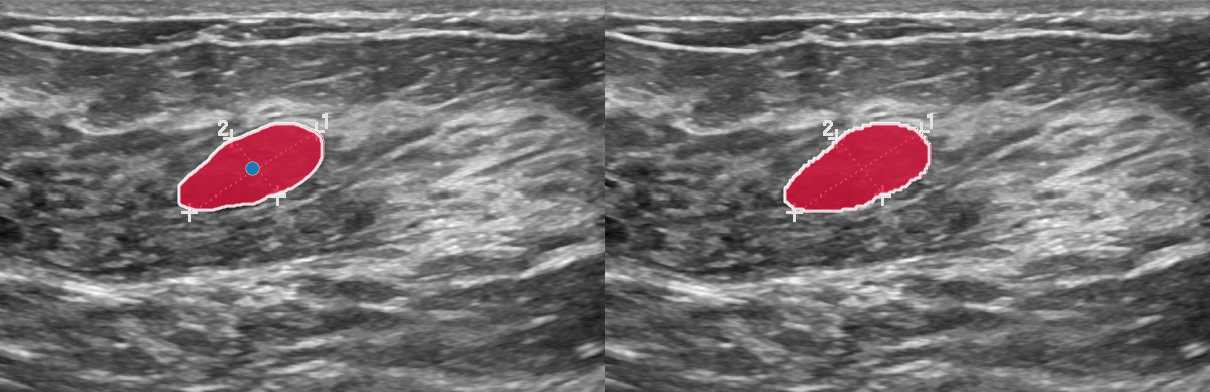

00002_32.png


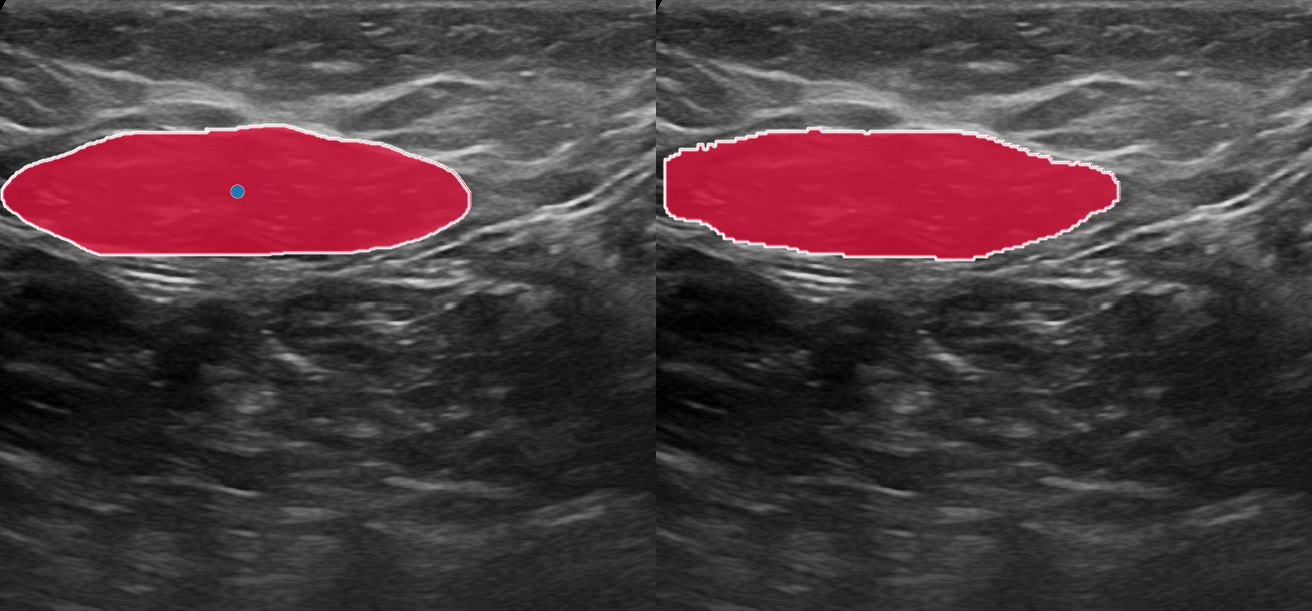

00003_418.png


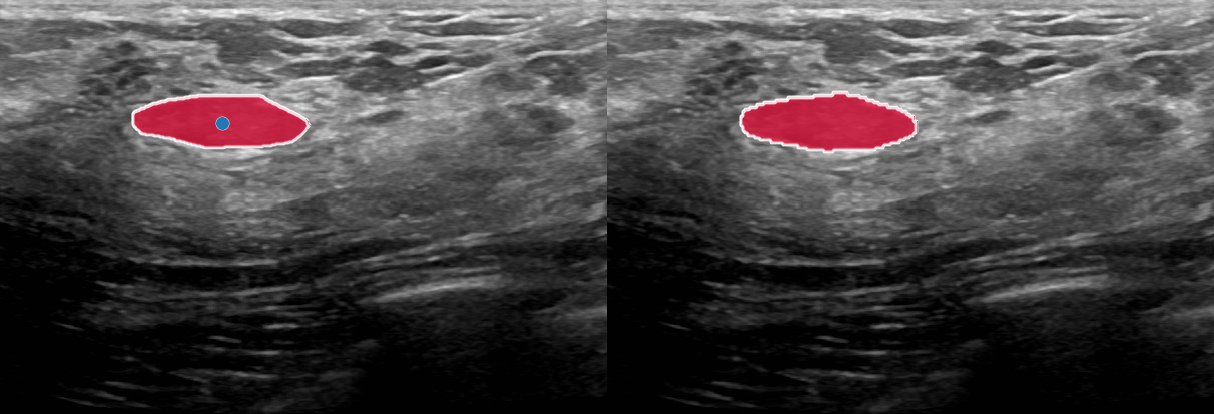

00004_203.png


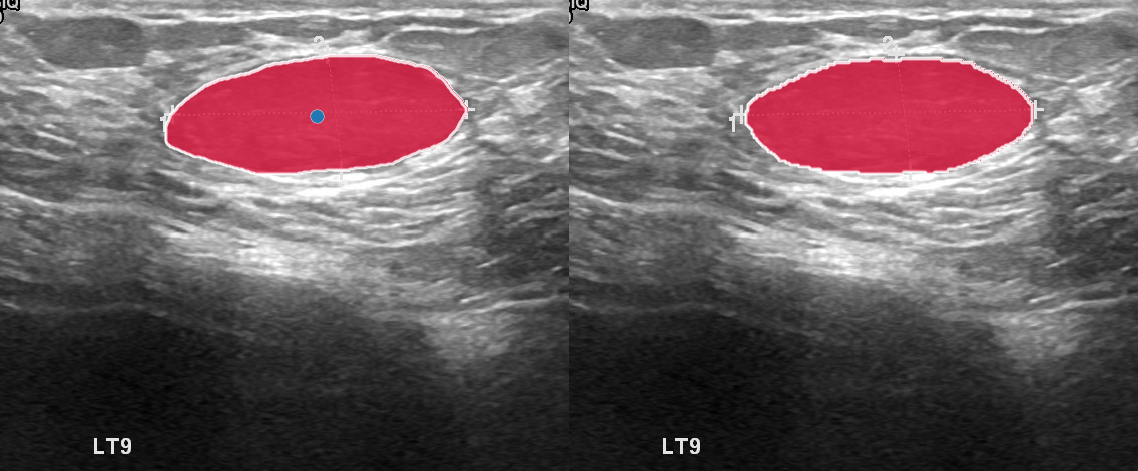

00005_182.png


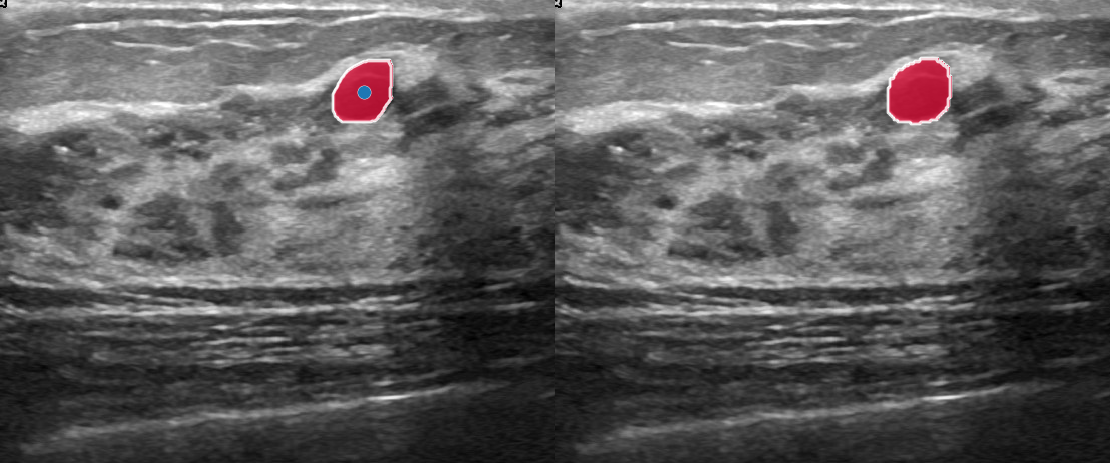

00006_370.png


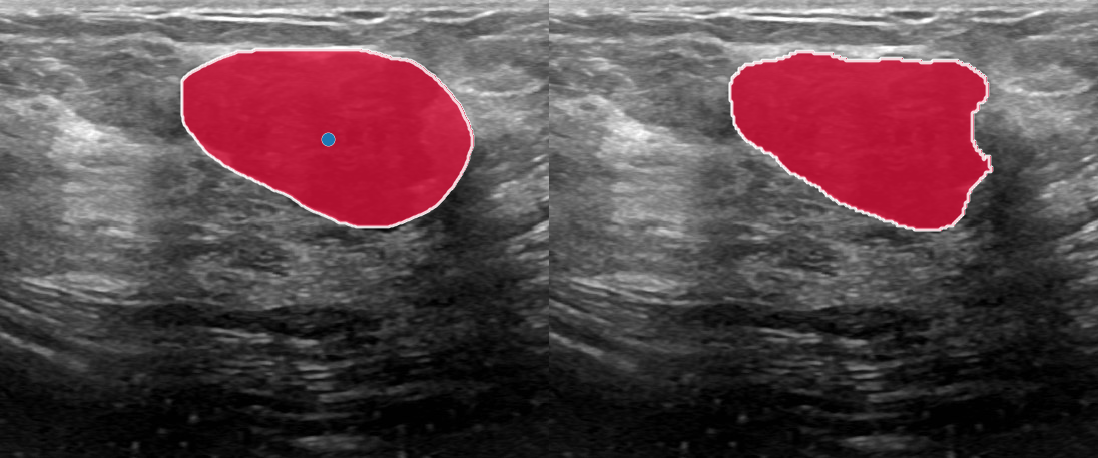

00007_441.png


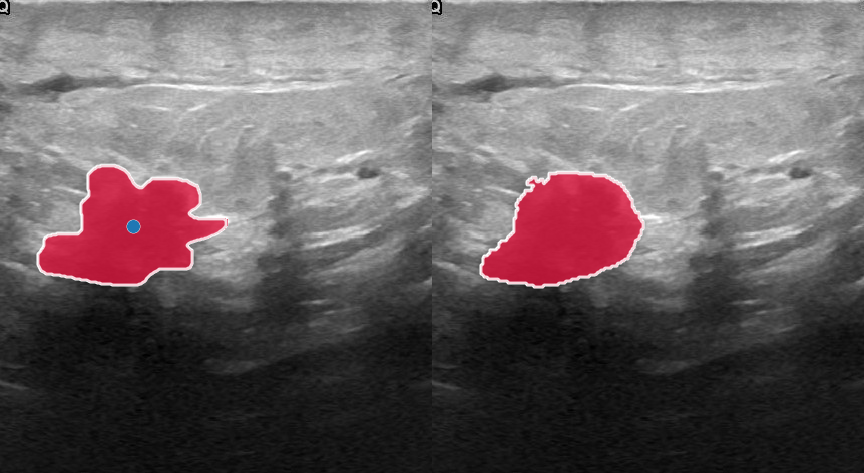

00008_589.png


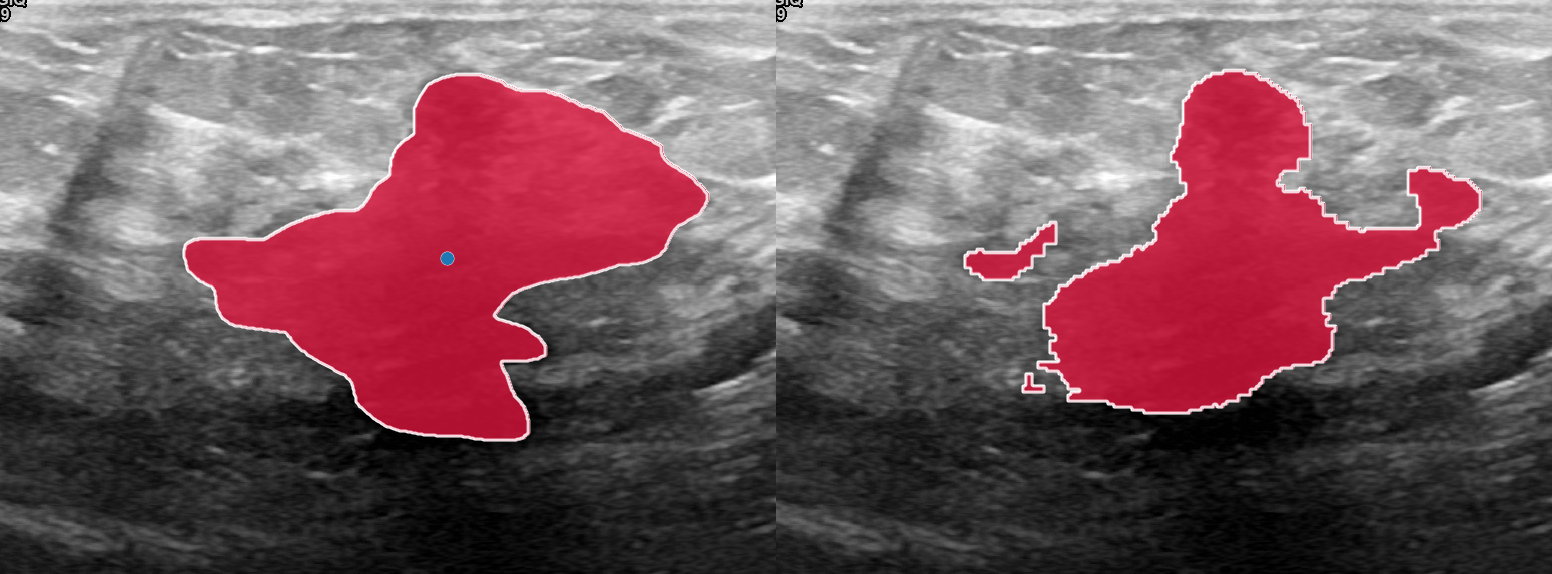

In [19]:
# Qualitative outputs generated by the official UltraSam visualizer.
vis_dir = Path(run_dir) / "official_test_transfer" / "visualizations"
print("Qualitative visualization directory:", vis_dir)

if vis_dir.exists():
    imgs = [p for p in vis_dir.rglob("*")
            if p.suffix.lower() in {".png", ".jpg", ".jpeg"}]
    print("Generated visualizations:", len(imgs))
    if imgs:
        from IPython.display import display
        from PIL import Image as PILImage
        for p in imgs[:8]:
            print(p.name)
            display(PILImage.open(p))
else:
    print("No visualization directory found.")


## Notes — RESUME version

- This notebook is based on the corrected V3 metric implementation.
- The training cell automatically searches `official_work_transfer` for the numerically latest `iter_*.pth` checkpoint.
- It launches MMDetection with `--resume <checkpoint>`, which restores the model, optimizer, LR scheduler, and iteration counter.
- It excludes `best_busi_Dice_iter_*.pth` from automatic latest-iteration selection so that continuation follows the latest training state.
- The existing training log is appended to rather than overwritten.
- If no regular iteration checkpoint is found, the cell stops with an explicit error instead of silently restarting from scratch.
- After resuming, verify that the first training iteration is above the detected checkpoint iteration. If you see `Iter(train) [50/10000]`, stop the run.
- Validation/test remains GT-box-prompted segmentation and should be reported as prompted segmentation.


SELECTED TEST SAMPLE
Sample Index : 3
Image ID     : 4
Image        : 203.png
Mask         : 203.png
Bounding Box : [166, 56, 302, 120]

Number of existing prediction images: 50

UltraSam prediction found:
C:\Users\pro\Breast cancer aldubayani models\busi_clean_benchmark\ultrasam_box_prompt_transfer\seed42\official_test_transfer\visualizations\00004_203.png

FINAL FIGURE SAVED SUCCESSFULLY
Saved to:
C:\Users\pro\Breast cancer aldubayani models\Advanced models\Ultrasam\Paper 2026\UltraSam_Result_203.png


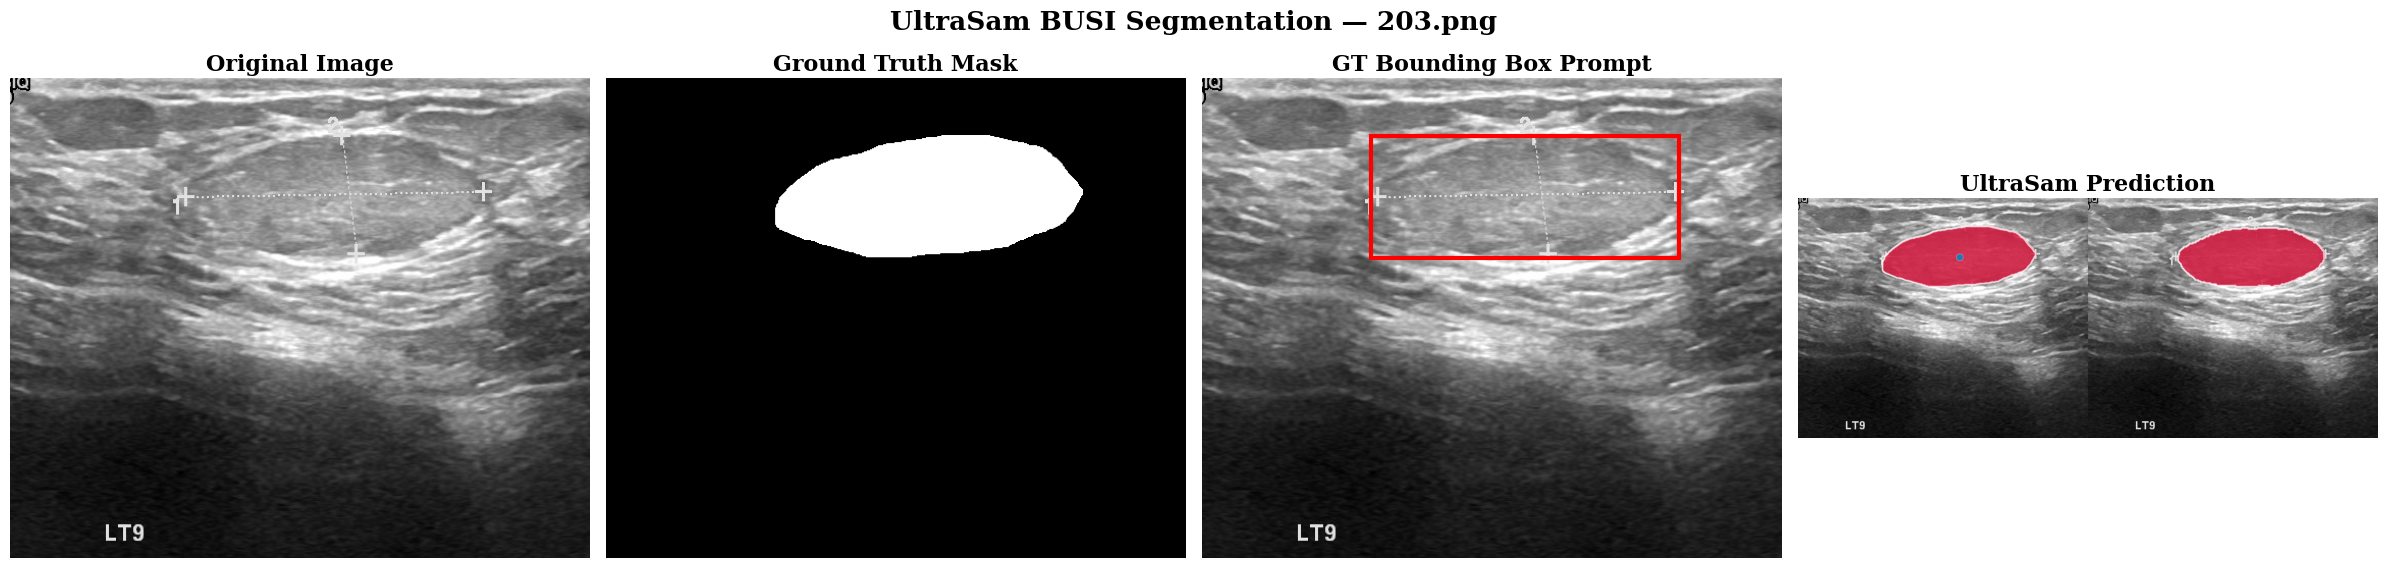

In [30]:
# ============================================================
# UltraSam BUSI — FINAL QUALITATIVE VISUALIZATION
#
# DISPLAY:
# 1. Original Image
# 2. Ground Truth Mask
# 3. Original Image + GT Bounding Box
# 4. Existing UltraSam Prediction
#
# SAVE:
# C:\Users\pro\Breast cancer aldubayani models\
# Advanced models\Ultrasam\Paper 2026
#
# IMPORTANT:
# No new inference is performed.
# The prediction generated by the official UltraSam test is used.
# ============================================================

import json
import cv2
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image
from matplotlib.patches import Rectangle


# ============================================================
# 1. SELECT TEST SAMPLE
# ============================================================

SAMPLE_INDEX = 3
# Change to:
# 0, 1, 2, 3, 4, ...


# ============================================================
# 2. PATHS
# ============================================================

# Test manifest
manifest_path = (
    Path(ULTRA_COCO_ROOT)
    / "test"
    / "manifest.json"
)

# Existing UltraSam prediction visualizations
vis_dir = (
    Path(run_dir)
    / "official_test_transfer"
    / "visualizations"
)

# ------------------------------------------------------------
# SAVE DIRECTORY
# ------------------------------------------------------------

save_dir = Path(
    r"C:\Users\pro\Breast cancer aldubayani models\Advanced models\Ultrasam\Paper 2026"
)

# Create directory automatically if it does not exist
save_dir.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 3. CHECK PATHS
# ============================================================

if not manifest_path.exists():
    raise FileNotFoundError(
        f"Manifest not found:\n{manifest_path}"
    )

if not vis_dir.exists():
    raise FileNotFoundError(
        f"Visualization directory not found:\n{vis_dir}\n\n"
        "Run the official UltraSam TEST cell first."
    )


# ============================================================
# 4. READ TEST MANIFEST
# ============================================================

with open(
    manifest_path,
    "r",
    encoding="utf-8"
) as f:

    manifest = json.load(f)


if len(manifest) == 0:
    raise RuntimeError(
        "Test manifest is empty."
    )


if SAMPLE_INDEX < 0 or SAMPLE_INDEX >= len(manifest):

    raise IndexError(
        f"SAMPLE_INDEX={SAMPLE_INDEX}, "
        f"but the test set contains "
        f"{len(manifest)} samples."
    )


# ============================================================
# 5. SELECT SAMPLE
# ============================================================

sample = manifest[SAMPLE_INDEX]


image_id = int(
    sample["image_id"]
)

image_path = Path(
    sample["image_path"]
)

mask_path = Path(
    sample["mask_path"]
)


# ============================================================
# 6. GET GROUND-TRUTH BOUNDING BOX
# ============================================================

x, y, w, h = sample["bbox_xywh"]

x = int(x)
y = int(y)
w = int(w)
h = int(h)


# ============================================================
# 7. PRINT SAMPLE INFORMATION
# ============================================================

print("=" * 80)
print("SELECTED TEST SAMPLE")
print("=" * 80)

print(
    "Sample Index :",
    SAMPLE_INDEX
)

print(
    "Image ID     :",
    image_id
)

print(
    "Image        :",
    image_path.name
)

print(
    "Mask         :",
    mask_path.name
)

print(
    "Bounding Box :",
    [x, y, w, h]
)

print("=" * 80)


# ============================================================
# 8. LOAD ORIGINAL IMAGE
# ============================================================
# This is the completely CLEAN original image.
# No mask.
# No bounding box.
# No prediction.
# ============================================================

original_bgr = cv2.imread(
    str(image_path),
    cv2.IMREAD_COLOR
)


if original_bgr is None:

    raise FileNotFoundError(
        f"Cannot read original image:\n"
        f"{image_path}"
    )


original_rgb = cv2.cvtColor(
    original_bgr,
    cv2.COLOR_BGR2RGB
)


# ============================================================
# 9. LOAD GROUND TRUTH MASK
# ============================================================

gt_mask_raw = cv2.imread(
    str(mask_path),
    cv2.IMREAD_GRAYSCALE
)


if gt_mask_raw is None:

    raise FileNotFoundError(
        f"Cannot read GT mask:\n"
        f"{mask_path}"
    )


# Convert to binary mask
gt_mask = (
    gt_mask_raw > 127
).astype(np.uint8)


# ============================================================
# 10. FIND EXISTING ULTRASAM PREDICTIONS
# ============================================================

prediction_files = sorted([
    p
    for p in vis_dir.rglob("*")
    if p.suffix.lower()
    in [
        ".png",
        ".jpg",
        ".jpeg"
    ]
])


print(
    "\nNumber of existing prediction images:",
    len(prediction_files)
)


if len(prediction_files) == 0:

    raise RuntimeError(
        f"No prediction images were found in:\n"
        f"{vis_dir}\n\n"
        "Run the official UltraSam TEST cell first."
    )


# ============================================================
# 11. FIND PREDICTION CORRESPONDING TO SELECTED IMAGE
# ============================================================

prediction_path = None


# ------------------------------------------------------------
# METHOD 1
# Image ID + original filename
# ------------------------------------------------------------

expected_name = (
    f"{image_id:05d}_{image_path.name}"
)


for p in prediction_files:

    if p.name == expected_name:

        prediction_path = p

        break


# ------------------------------------------------------------
# METHOD 2
# Exact original filename
# ------------------------------------------------------------

if prediction_path is None:

    for p in prediction_files:

        if p.name == image_path.name:

            prediction_path = p

            break


# ------------------------------------------------------------
# METHOD 3
# Original filename contained inside prediction filename
# ------------------------------------------------------------

if prediction_path is None:

    for p in prediction_files:

        if image_path.name in p.name:

            prediction_path = p

            break


# ------------------------------------------------------------
# METHOD 4
# Match image stem
# Example:
# 222.png -> 222
# ------------------------------------------------------------

if prediction_path is None:

    for p in prediction_files:

        if image_path.stem in p.stem:

            prediction_path = p

            break


# ------------------------------------------------------------
# METHOD 5
# Match COCO image ID prefix
# ------------------------------------------------------------

if prediction_path is None:

    id_prefix = (
        f"{image_id:05d}_"
    )

    for p in prediction_files:

        if p.name.startswith(
            id_prefix
        ):

            prediction_path = p

            break


# ============================================================
# 12. LOAD EXISTING ULTRASAM PREDICTION
# ============================================================

prediction_rgb = None


if prediction_path is not None:

    print(
        "\nUltraSam prediction found:"
    )

    print(
        prediction_path
    )


    prediction_rgb = np.array(

        Image.open(
            prediction_path
        ).convert("RGB")

    )


else:

    print(
        "\nWARNING:"
        " Could not automatically match "
        "the UltraSam prediction."
    )


    print(
        "\nFirst available visualization files:"
    )


    for p in prediction_files[:20]:

        print(
            "  ",
            p.name
        )


# ============================================================
# 13. CREATE FINAL FIGURE
# ============================================================

fig, axes = plt.subplots(
    1,
    4,
    figsize=(24, 6)
)


# ============================================================
# PANEL 1
# ORIGINAL IMAGE — CLEAN
# ============================================================

axes[0].imshow(
    original_rgb
)


axes[0].set_title(
    "Original Image",
    fontsize=16,
    fontweight="bold"
)


axes[0].axis(
    "off"
)


# ============================================================
# PANEL 2
# GROUND TRUTH MASK
# ============================================================

axes[1].imshow(
    gt_mask,
    cmap="gray"
)


axes[1].set_title(
    "Ground Truth Mask",
    fontsize=16,
    fontweight="bold"
)


axes[1].axis(
    "off"
)


# ============================================================
# PANEL 3
# ORIGINAL IMAGE + GT BOUNDING BOX
# ============================================================

axes[2].imshow(
    original_rgb
)


bbox_rectangle = Rectangle(

    (x, y),

    w,

    h,

    fill=False,

    edgecolor="red",

    linewidth=3
)


axes[2].add_patch(
    bbox_rectangle
)


axes[2].set_title(
    "GT Bounding Box Prompt",
    fontsize=16,
    fontweight="bold"
)


axes[2].axis(
    "off"
)


# ============================================================
# PANEL 4
# EXISTING ULTRASAM PREDICTION
# ============================================================

if prediction_rgb is not None:

    axes[3].imshow(
        prediction_rgb
    )


else:

    axes[3].text(

        0.5,

        0.5,

        "Prediction not found",

        horizontalalignment="center",

        verticalalignment="center",

        fontsize=16
    )


axes[3].set_title(
    "UltraSam Prediction",
    fontsize=16,
    fontweight="bold"
)


axes[3].axis(
    "off"
)


# ============================================================
# 14. MAIN TITLE
# ============================================================

plt.suptitle(

    f"UltraSam BUSI Segmentation — {image_path.name}",

    fontsize=19,

    fontweight="bold"
)


plt.tight_layout()


# ============================================================
# 15. SAVE FINAL FIGURE
# ============================================================

# Example:
# UltraSam_Result_222.png

save_path = (
    save_dir
    / f"UltraSam_Result_{image_path.stem}.png"
)


plt.savefig(

    save_path,

    dpi=300,

    bbox_inches="tight",

    facecolor="white"
)


# ============================================================
# 16. CONFIRM SAVE LOCATION
# ============================================================

print("\n" + "=" * 80)

print(
    "FINAL FIGURE SAVED SUCCESSFULLY"
)

print("=" * 80)

print(
    "Saved to:"
)

print(
    save_path
)

print("=" * 80)


# ============================================================
# 17. DISPLAY FINAL FIGURE
# ============================================================

plt.show()

In [31]:
# ============================================================
# UltraSam (Ours) — Efficiency Benchmark
# Measure:
#   1. Average Dice
#   2. FPS
#   3. Peak GPU Memory (MB)
#
# IMPORTANT:
# Run this after CUSTOM_CONFIG and BEST_ULTRASAM_CKPT exist.
# ============================================================

import time
import gc
import numpy as np
import torch

from mmengine.config import Config
from mmengine.runner import Runner
from mmengine.runner.checkpoint import load_checkpoint


# ============================================================
# SETTINGS
# ============================================================

WARMUP_BATCHES = 5

device = torch.device(
    "cuda:0" if torch.cuda.is_available() else "cpu"
)

print("=" * 70)
print("UltraSam Efficiency Benchmark")
print("=" * 70)

print("Device     :", device)
print("Config     :", CUSTOM_CONFIG)
print("Checkpoint :", BEST_ULTRASAM_CKPT)

if torch.cuda.is_available():
    print("GPU        :", torch.cuda.get_device_name(0))

print("=" * 70)


# ============================================================
# CLEAN GPU MEMORY
# ============================================================

gc.collect()

if torch.cuda.is_available():

    torch.cuda.empty_cache()

    torch.cuda.reset_peak_memory_stats()

    torch.cuda.synchronize()


# ============================================================
# BUILD RUNNER
# ============================================================

cfg = Config.fromfile(
    str(CUSTOM_CONFIG)
)

cfg.load_from = None

runner = Runner.from_cfg(cfg)


# ============================================================
# LOAD CHECKPOINT
# ============================================================

load_checkpoint(
    runner.model,
    str(BEST_ULTRASAM_CKPT),
    map_location="cpu"
)


# ============================================================
# MODEL
# ============================================================

model = runner.model

model.eval()


if torch.cuda.is_available():

    model = model.to(device)


# ============================================================
# TEST DATALOADER
# ============================================================

test_loader = runner.test_dataloader


print("\nTest batches:", len(test_loader))


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def to_numpy_mask(mask):

    if mask is None:
        return None

    if hasattr(mask, "to_ndarray"):
        mask = mask.to_ndarray()

    elif hasattr(mask, "tensor"):
        mask = mask.tensor

    elif hasattr(mask, "data"):
        mask = mask.data

    if torch.is_tensor(mask):
        mask = mask.detach().cpu().numpy()

    mask = np.asarray(mask)

    return mask


def get_best_prediction(pred_instances):

    if pred_instances is None:
        return None

    if not hasattr(pred_instances, "masks"):
        return None

    masks = to_numpy_mask(
        pred_instances.masks
    )

    if masks is None:
        return None

    # --------------------------------------------------------
    # Normalize dimensions
    # --------------------------------------------------------

    if masks.ndim == 2:

        masks = masks[None, ...]

    elif masks.ndim == 4:

        masks = np.squeeze(
            masks,
            axis=1
        )

    # --------------------------------------------------------
    # Select highest-confidence prediction
    # --------------------------------------------------------

    if masks.shape[0] > 1:

        if hasattr(pred_instances, "scores"):

            scores = pred_instances.scores

            if torch.is_tensor(scores):
                scores = scores.detach().cpu().numpy()

            scores = np.asarray(scores)

            best_idx = int(
                np.argmax(scores)
            )

        else:

            best_idx = 0

        mask = masks[best_idx]

    else:

        mask = masks[0]

    # --------------------------------------------------------
    # Binary mask
    # --------------------------------------------------------

    if mask.dtype == bool:

        binary = mask

    else:

        binary = mask > 0.5

    return binary.astype(np.uint8)


def get_gt_mask(data_sample):

    gt = getattr(
        data_sample,
        "gt_instances",
        None
    )

    if gt is None:
        return None

    if not hasattr(gt, "masks"):
        return None

    masks = to_numpy_mask(
        gt.masks
    )

    if masks is None:
        return None

    if masks.ndim == 2:

        mask = masks

    elif masks.ndim >= 3:

        mask = masks[0]

    else:

        return None

    return (
        mask > 0
    ).astype(np.uint8)


def dice_score(pred, gt):

    pred = pred.astype(bool)

    gt = gt.astype(bool)

    intersection = np.logical_and(
        pred,
        gt
    ).sum()

    denominator = (
        pred.sum()
        +
        gt.sum()
    )

    if denominator == 0:

        return 1.0

    return (
        2.0 * intersection
        /
        denominator
    )


# ============================================================
# WARM-UP
# ============================================================

print("\nRunning warm-up...")

with torch.no_grad():

    for batch_idx, data_batch in enumerate(test_loader):

        if batch_idx >= WARMUP_BATCHES:
            break

        try:

            _ = model.test_step(
                data_batch
            )

        except Exception as e:

            print("\nERROR during warm-up:")
            print(e)

            raise


if torch.cuda.is_available():
    torch.cuda.synchronize()


print("Warm-up completed.")


# ============================================================
# RESET GPU MEMORY AFTER WARM-UP
# ============================================================

if torch.cuda.is_available():

    torch.cuda.empty_cache()

    torch.cuda.reset_peak_memory_stats()

    torch.cuda.synchronize()


# ============================================================
# BENCHMARK
# ============================================================

dice_scores = []

total_images = 0

total_time = 0.0


print("\nRunning benchmark...")


with torch.no_grad():

    for batch_idx, data_batch in enumerate(test_loader):

        # ----------------------------------------------------
        # Synchronize before timing
        # ----------------------------------------------------

        if torch.cuda.is_available():
            torch.cuda.synchronize()


        start_time = time.perf_counter()


        # ----------------------------------------------------
        # ULTRASAM INFERENCE
        # ----------------------------------------------------

        outputs = model.test_step(
            data_batch
        )


        # ----------------------------------------------------
        # Synchronize after inference
        # ----------------------------------------------------

        if torch.cuda.is_available():
            torch.cuda.synchronize()


        end_time = time.perf_counter()


        elapsed = (
            end_time
            -
            start_time
        )


        # ----------------------------------------------------
        # NUMBER OF IMAGES
        # ----------------------------------------------------

        batch_images = len(outputs)

        total_images += batch_images

        total_time += elapsed


        # ----------------------------------------------------
        # DICE
        # ----------------------------------------------------

        for output in outputs:

            pred_instances = getattr(
                output,
                "pred_instances",
                None
            )


            pred_mask = get_best_prediction(
                pred_instances
            )


            gt_mask = get_gt_mask(
                output
            )


            if (
                pred_mask is None
                or
                gt_mask is None
            ):
                continue


            # ------------------------------------------------
            # Resize prediction if needed
            # ------------------------------------------------

            if pred_mask.shape != gt_mask.shape:

                import cv2

                pred_mask = cv2.resize(

                    pred_mask.astype(
                        np.uint8
                    ),

                    (
                        gt_mask.shape[1],
                        gt_mask.shape[0]
                    ),

                    interpolation=cv2.INTER_NEAREST
                )


            d = dice_score(
                pred_mask,
                gt_mask
            )


            dice_scores.append(
                d
            )


        # ----------------------------------------------------
        # PROGRESS
        # ----------------------------------------------------

        print(
            f"\rBatch "
            f"{batch_idx + 1}/{len(test_loader)}",
            end=""
        )


print("\n")


# ============================================================
# CALCULATE FPS
# ============================================================

fps = (
    total_images
    /
    total_time
)


# ============================================================
# CALCULATE AVERAGE DICE
# ============================================================

if len(dice_scores) > 0:

    average_dice = (
        np.mean(dice_scores)
        *
        100
    )

else:

    average_dice = float("nan")


# ============================================================
# GPU MEMORY
# ============================================================

if torch.cuda.is_available():

    peak_gpu_memory_mb = (
        torch.cuda.max_memory_allocated()
        /
        (1024 ** 2)
    )

    peak_gpu_reserved_mb = (
        torch.cuda.max_memory_reserved()
        /
        (1024 ** 2)
    )

else:

    peak_gpu_memory_mb = float("nan")

    peak_gpu_reserved_mb = float("nan")


# ============================================================
# RESULTS
# ============================================================

print("=" * 70)

print(
    "UltraSam (Ours) — Efficiency Results"
)

print("=" * 70)


print(
    f"Test images          : "
    f"{total_images}"
)


print(
    f"Measured Dice cases  : "
    f"{len(dice_scores)}"
)


print(
    f"Average Dice         : "
    f"{average_dice:.2f}%"
)


print(
    f"Total inference time : "
    f"{total_time:.4f} s"
)


print(
    f"FPS                  : "
    f"{fps:.2f}"
)


print(
    f"Peak GPU allocated   : "
    f"{peak_gpu_memory_mb:.2f} MB"
)


print(
    f"Peak GPU reserved    : "
    f"{peak_gpu_reserved_mb:.2f} MB"
)


print("=" * 70)


# ============================================================
# COPY-READY VALUES FOR YOUR FIGURE
# ============================================================

ULTRASAM_DICE = average_dice
ULTRASAM_FPS = fps
ULTRASAM_GPU_MB = peak_gpu_memory_mb


print("\nValues for plotting:")

print(
    f"ULTRASAM_DICE   = "
    f"{ULTRASAM_DICE:.2f}"
)

print(
    f"ULTRASAM_FPS    = "
    f"{ULTRASAM_FPS:.2f}"
)

print(
    f"ULTRASAM_GPU_MB = "
    f"{ULTRASAM_GPU_MB:.2f}"
)

UltraSam Efficiency Benchmark
Device     : cuda:0
Config     : C:\Users\pro\Breast cancer aldubayani models\busi_clean_benchmark\ultrasam_box_prompt_transfer\seed42\UltraSam_BUSI_Transfer_FrozenBackbone.py
Checkpoint : C:\Users\pro\Breast cancer aldubayani models\busi_clean_benchmark\ultrasam_box_prompt_transfer\seed42\official_work_transfer\best_busi_Dice_iter_6500.pth
GPU        : NVIDIA GeForce RTX 4070 Laptop GPU
09/22 01:34:06 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: win32
    Python: 3.8.20 (default, Oct  3 2024, 15:19:54) [MSC v.1929 64 bit (AMD64)]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 2034101417
    GPU 0: NVIDIA GeForce RTX 4070 Laptop GPU
    CUDA_HOME: None
    MSVC: n/a, reason: fileno
    PyTorch: 2.0.0+cu118
    PyTorch compiling details: PyTorch built with:
  - C++ Version: 199711
  - MSVC 193431937
  - Intel(R) Math Kernel Library Version 2020.0.2 Product 

C:\Users\pro\anaconda3\envs\UltraSam\lib\site-packages\mmengine\utils\manager.py:113: UserWarning: <class 'endosam.visualization.point_visualization.PointVisualizer'> instance named of visualizer has been created, the method `get_instance` should not accept any other arguments
  warnings.warn(


09/22 01:34:12 - mmengine - INFO - Distributed training is not used, all SyncBatchNorm (SyncBN) layers in the model will be automatically reverted to BatchNormXd layers if they are used.
09/22 01:34:12 - mmengine - INFO - Hooks will be executed in the following order:
before_run:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) MonkeyPatchHook                    
(BELOW_NORMAL) LoggerHook                         
 -------------------- 
before_train:
(VERY_HIGH   ) RuntimeInfoHook                    
(VERY_HIGH   ) FreezeUltraSamBackboneHook         
(NORMAL      ) IterTimerHook                      
(VERY_LOW    ) CheckpointHook                     
 -------------------- 
before_train_epoch:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(NORMAL      ) DistSamplerSeedHook                
 -------------------- 
before_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                    
(VERY_HIGH   ) FreezeUltraSamBackbon

AssertionError: was expecting embedding dimension of 128, but got 256